# FarmTech Solutions — Fase 5
## Predição de rendimento de safra e análise de tendências por clusterização

**Autora:** Leticia Eltermann — **RM 568645**

---

### Contexto

A FarmTech Solutions avalia se as condições climáticas registradas em sua área de
produção permitem antecipar o rendimento das culturas. O conjunto `crop_yield.csv`
traz, para quatro culturas — cacau, dendê, arroz e seringueira — o rendimento
observado ao lado de quatro variáveis climáticas.

### Variáveis

| Coluna | Descrição | Unidade |
|---|---|---|
| `Crop` | cultura | categórica, 4 níveis |
| `Precipitation (mm day-1)` | precipitação | mm |
| `Specific Humidity at 2 Meters (g/kg)` | umidade específica a 2 m | g/kg |
| `Relative Humidity at 2 Meters (%)` | umidade relativa a 2 m | % |
| `Temperature at 2 Meters (C)` | temperatura a 2 m | °C |
| `Yield` | rendimento | discutida na seção 2 |

### Objetivo

1. Caracterizar o conjunto e a relação entre clima e rendimento.
2. Agrupar as condições climáticas em perfis e identificar cenários discrepantes.
3. Treinar **cinco algoritmos, distribuídos em quatro famílias** — linear
   regularizada (Regressão Linear e Ridge), baseada em distância (KNN), ensemble
   por *bagging* (Random Forest) e ensemble por *boosting* (Gradient Boosting) — e
   medir o que cada um acrescenta sobre um piso de comparação explícito.

O critério que organiza todo o trabalho é este: **um modelo só é útil se superar o
que já se sabe sem ele.** Como a seção 5 mostra, saber apenas a cultura já explica
quase toda a variância do rendimento — é contra esse piso, e não contra zero, que
cada modelo é julgado aqui.

---
## 2. Carga e preparação

Duas decisões precisam de justificativa antes de qualquer análise: a **unidade do
alvo** e a criação de um **identificador de observação**.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
from sklearn.base import BaseEstimator, RegressorMixin, clone
from sklearn.cluster import DBSCAN, KMeans
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import (
    mean_absolute_error,
    r2_score,
    root_mean_squared_error,
    silhouette_score,
)
from sklearn.model_selection import GroupKFold, GroupShuffleSplit
from sklearn.neighbors import KNeighborsRegressor, NearestNeighbors
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

RANDOM_STATE = 42
CAMINHO_CSV = "crop_yield.csv"

HG_HA_POR_T_HA = 10_000

ALFA = 0.05
N_PERMUTACOES = 100_000
QUARTIL_INFERIOR = 0.25
QUARTIL_SUPERIOR = 0.75
# 16 pares x (Pearson + Spearman + parcial) = 48, mais 8 permutacoes, 4 Kruskal-Wallis,
# 1 Shapiro-Wilk e 2 testes t pareados dos ganhos de validacao.
N_TESTES_HIPOTESE = 63
# Correlacao parcial consome um grau de liberdade a mais que a simples: n - 2 - 1.
PARAMETROS_CORRELACAO_PARCIAL = 3

K_CANDIDATOS = range(2, 7)
K_CLUSTERS = 3
ROTULOS_PERFIL = ("Chuvoso e úmido", "Seco e quente", "Seco e ameno")
N_INICIALIZACOES = 10
IQR_FATOR = 1.5
DBSCAN_MIN_AMOSTRAS = 4
PERCENTIL_EPS = 90

TESTE_FRACAO = 0.2
N_FOLDS = 5
PREFIXO_RMSE_CULTURA = "RMSE por cultura: "
RIDGE_ALPHA = 1.0
KNN_VIZINHOS = 5
N_ARVORES = 300
PROFUNDIDADE_GB = 3
N_REPETICOES_IMPORTANCIA = 30

BINS_HISTOGRAMA = 12
FIG_PADRAO = (10, 4)
FIG_LARGA = (12, 4)
FIG_GRADE = (11, 8)
FIG_PAINEL = (14, 3.5)

sns.set_theme(style="whitegrid")

In [2]:
df = pd.read_csv(CAMINHO_CSV)
COLUNAS_CLIMA = [c for c in df.columns if c not in ("Crop", "Yield")]
# Selecao por nome, nao por posicao: a ordem das colunas do CSV nao e contrato.
COL_PRECIPITACAO = next(c for c in COLUNAS_CLIMA if c.startswith("Precipitation"))
COL_TEMPERATURA = next(c for c in COLUNAS_CLIMA if c.startswith("Temperature"))

df["Yield_t_ha"] = df["Yield"] / HG_HA_POR_T_HA

df.groupby("Crop")["Yield"].agg(["mean", "min", "max"]).div(HG_HA_POR_T_HA).round(3).rename(
    columns={"mean": "média (t/ha)", "min": "mínimo (t/ha)", "max": "máximo (t/ha)"}
)

,média (t/ha),mínimo (t/ha),máximo (t/ha)
Crop,,,
"Cocoa, beans",0.888,0.576,1.306
Oil palm fruit,17.580,14.242,20.340
"Rice, paddy",3.210,2.469,4.255
"Rubber, natural",0.782,0.525,1.028


In [3]:
blocos = {cultura: g[COLUNAS_CLIMA].reset_index(drop=True) for cultura, g in df.groupby("Crop")}
referencia = next(iter(blocos.values()))
identicos = {cultura: bloco.equals(referencia) for cultura, bloco in blocos.items()}

# Toda a estrategia anti-vazamento da secao 5 repousa nisto: se a premissa cair, o
# notebook deve parar em vez de produzir metricas sobre um agrupamento invalido.
assert all(identicos.values()), f"sequencia climatica difere entre culturas: {identicos}"

df["obs_id"] = df.groupby("Crop").cumcount()
CULTURAS = sorted(df["Crop"].unique())
MEDIA_POR_CULTURA = df.groupby("Crop")["Yield_t_ha"].mean()
clima_39 = df.drop_duplicates("obs_id").set_index("obs_id")[COLUNAS_CLIMA].sort_index()

print(f"blocos climaticos identicos ao de referencia: {identicos}")
print(f"observacoes climaticas distintas: {len(clima_39)} | linhas no arquivo: {len(df)}")

blocos climaticos identicos ao de referencia: {'Cocoa, beans': True, 'Oil palm fruit': True, 'Rice, paddy': True, 'Rubber, natural': True}
observacoes climaticas distintas: 39 | linhas no arquivo: 156


### A unidade do alvo não é tonelada por hectare

O enunciado descreve o rendimento em toneladas por hectare, mas a média bruta do
dendê é **175.805** — valor fisicamente impossível para qualquer cultura. Dividindo
por 10.000, as quatro culturas caem nas faixas agronômicas esperadas: **0,888 t/ha**
para o cacau, **17,580 t/ha** para o cacho de dendê, **3,210 t/ha** para o arroz em
casca e **0,782 t/ha** para a borracha natural.

A unidade original é portanto **hg/ha** (hectograma por hectare), convenção do
FAOSTAT para o elemento 5419 "Yield". A conversão não altera nenhuma métrica
relativa — R², correlações e ganhos percentuais são invariantes — mas torna cada
gráfico e cada RMSE legível em unidade agronômica real. Todo o restante do trabalho
usa `Yield_t_ha`.

*Ressalva:* a identificação da unidade é uma **inferência** apoiada na
plausibilidade agronômica das quatro médias resultantes e na convenção do FAOSTAT.
O arquivo não documenta sua unidade.

### Por que existe um identificador de observação

Os quatro blocos climáticos são **idênticos entre si, linha a linha e na mesma
ordem** — a verificação retorna `True` para as quatro culturas. Não é apenas que os
mesmos 39 valores apareçam em cada cultura: é a mesma sequência, na mesma posição.

Isso legitima `obs_id = groupby('Crop').cumcount()` como identificador da observação
climática compartilhada, e é o que torna possível, na seção 5, separar treino e
teste sem que a mesma condição climática apareça dos dois lados. Como toda a
estratégia anti-vazamento depende dessa premissa, ela é imposta por `assert` e não
apenas impressa: se a sequência divergisse entre culturas, o notebook pararia em vez
de produzir métricas sobre um agrupamento inválido.

A consequência mais importante do arquivo está nesta linha: **156 registros carregam
apenas 39 observações climáticas distintas.**

---
## 3. Análise exploratória

In [4]:
print(f"linhas x colunas: {df.shape}")
print(f"valores ausentes: {df.isna().sum().sum()} | linhas duplicadas: {df.duplicated().sum()}")
print(f"linhas por cultura: {df['Crop'].value_counts().to_dict()}")
print(f"clima apos drop_duplicates: {df[COLUNAS_CLIMA].drop_duplicates().shape}")
print(f"valores unicos de rendimento por cultura: {df.groupby('Crop')['Yield'].nunique().to_dict()}")

df.groupby("Crop")["Yield_t_ha"].describe().round(3)

linhas x colunas: (156, 8)
valores ausentes: 0 | linhas duplicadas: 0
linhas por cultura: {'Cocoa, beans': 39, 'Oil palm fruit': 39, 'Rice, paddy': 39, 'Rubber, natural': 39}
clima apos drop_duplicates: (39, 4)
valores unicos de rendimento por cultura: {'Cocoa, beans': 38, 'Oil palm fruit': 39, 'Rice, paddy': 39, 'Rubber, natural': 39}


,count,mean,std,min,25%,50%,75%,max
Crop,,,,,,,,
"Cocoa, beans",39.0,0.888,0.175,0.576,0.773,0.885,0.992,1.306
Oil palm fruit,39.0,17.580,1.492,14.242,16.602,17.563,18.523,20.340
"Rice, paddy",39.0,3.210,0.479,2.469,2.829,3.110,3.610,4.255
"Rubber, natural",39.0,0.782,0.160,0.525,0.640,0.782,0.927,1.028


O conjunto está íntegro: **nenhum valor ausente, nenhuma linha duplicada**, e as
quatro culturas com exatamente 39 registros cada.

O número decisivo é o `drop_duplicates` das colunas climáticas: **(39, 4)**. As 156
linhas contêm 39 pontos de informação climática, repetidos quatro vezes. Toda
inferência sobre clima neste notebook tem, portanto, **n = 39, não n = 156** —
tratar 156 como tamanho amostral quadruplicaria artificialmente a evidência.

O cacau apresenta 38 valores únicos de rendimento em 39 registros. O valor repetido
ocorre em duas observações com climas completamente distintos e não adjacentes: é
coincidência numérica em uma série de 39 pontos, não registro duplicado, e não exige
tratamento.

As escalas confirmam o que a modelagem terá de enfrentar: o dendê tem média
17,580 t/ha e desvio 1,492, enquanto a borracha tem média 0,782 e desvio 0,160.

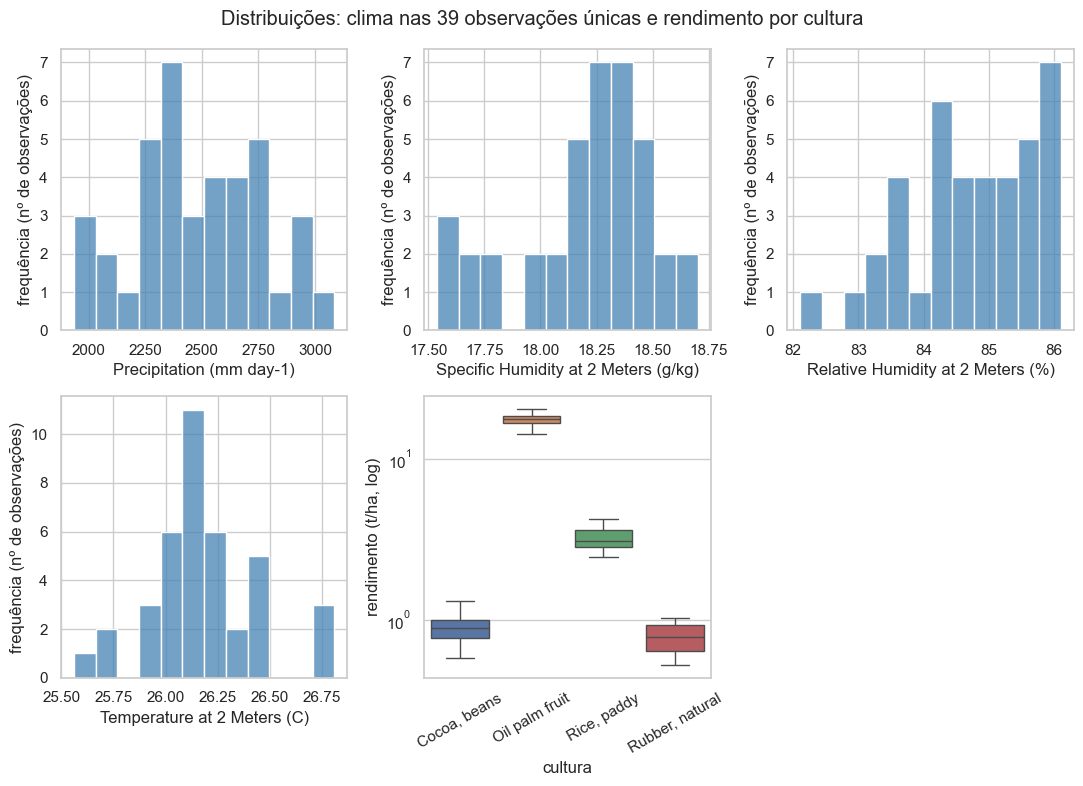

razao entre a maior e a menor media de rendimento: 22.47x
assimetria (skew) das variaveis climaticas:
Precipitation (mm day-1)                0.033
Specific Humidity at 2 Meters (g/kg)   -0.723
Relative Humidity at 2 Meters (%)      -0.553
Temperature at 2 Meters (C)             0.388

faixas de rendimento (t/ha):
                     min      max
Crop                             
Cocoa, beans      0.5765   1.3056
Oil palm fruit   14.2425  20.3399
Rice, paddy       2.4686   4.2550
Rubber, natural   0.5249   1.0285

observacoes de cacau dentro da faixa da borracha: 32 de 39


In [5]:
figura, eixos = plt.subplots(2, 3, figsize=FIG_GRADE)
for eixo, coluna in zip(eixos.ravel(), COLUNAS_CLIMA):
    sns.histplot(clima_39[coluna], bins=BINS_HISTOGRAMA, ax=eixo, color="steelblue")
    eixo.set_xlabel(coluna)
    eixo.set_ylabel("frequência (nº de observações)")

sns.boxplot(data=df, x="Crop", y="Yield_t_ha", hue="Crop", legend=False, ax=eixos[1, 1])
eixos[1, 1].set_yscale("log")
eixos[1, 1].set_xlabel("cultura")
eixos[1, 1].set_ylabel("rendimento (t/ha, log)")
eixos[1, 1].tick_params(axis="x", rotation=30)
eixos[1, 2].axis("off")

figura.suptitle(f"Distribuições: clima nas {len(clima_39)} observações únicas e rendimento por cultura")
figura.tight_layout()
plt.show()

faixas = df.groupby("Crop")["Yield_t_ha"].agg(["min", "max"])
print(f"razao entre a maior e a menor media de rendimento: "
      f"{MEDIA_POR_CULTURA.max() / MEDIA_POR_CULTURA.min():.2f}x")
print(f"assimetria (skew) das variaveis climaticas:\n{clima_39.skew().round(3).to_string()}")
print(f"\nfaixas de rendimento (t/ha):\n{faixas.round(4).to_string()}")

sobreposicao = df[(df["Crop"] == "Cocoa, beans") & df["Yield_t_ha"].between(*faixas.loc["Rubber, natural"])]
print(f"\nobservacoes de cacau dentro da faixa da borracha: {len(sobreposicao)} de "
      f"{(df['Crop'] == 'Cocoa, beans').sum()}")

As variáveis climáticas ocupam faixas estreitas — a temperatura varia entre 25,56 °C
e 26,81 °C, pouco mais de um grau ao longo de todas as 39 observações. Essa amplitude
curta antecipa um problema: há pouca variação climática disponível para explicar
variação de rendimento.

A assimetria calculada mostra que elas **não são todas simétricas**. Precipitação
(0,033) e temperatura (0,388) são aproximadamente simétricas; a umidade específica
(**−0,723**) e a relativa (**−0,553**) têm assimetria moderada à esquerda. Como
Pearson pressupõe normalidade aproximada, esses dois casos pedem que o Spearman da
tabela seguinte seja lido em paralelo.

O boxplot exige escala logarítmica para ser legível, e a razão impressa diz por quê:
**22,47×** entre a média do dendê e a da borracha. Essa razão é o motivo de o alvo
ser modelado em log na seção 5 e de as métricas serem reportadas também por cultura:
em escala bruta, o erro do dendê domina qualquer média global e as outras três
culturas tornam-se invisíveis na métrica.

**As faixas de rendimento não são disjuntas.** O cacau vai de 0,5765 a 1,3056 t/ha e
a borracha de 0,5249 a 1,0285 — e **32 das 39 observações de cacau caem dentro da
faixa da borracha**. O que separa as culturas em blocos bem definidos é o dendê
(14,24–20,34 t/ha) e, em menor grau, o arroz (2,47–4,26). Esse detalhe importa para
ler corretamente a seção 5: o R² altíssimo do baseline vem da distância do dendê aos
demais, não de as quatro culturas ocuparem intervalos separados.

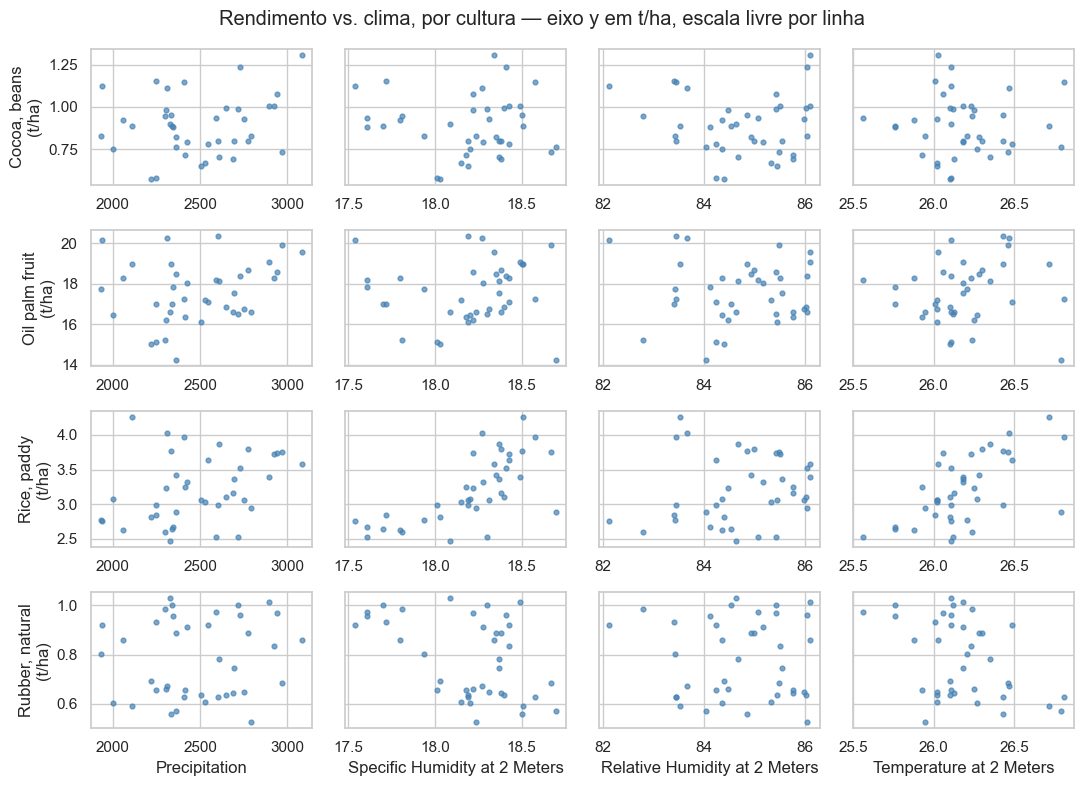

In [6]:
figura, eixos = plt.subplots(len(CULTURAS), len(COLUNAS_CLIMA), figsize=FIG_GRADE, sharey="row")
for i, cultura in enumerate(CULTURAS):
    sub = df[df["Crop"] == cultura]
    for j, coluna in enumerate(COLUNAS_CLIMA):
        eixos[i, j].scatter(sub[coluna], sub["Yield_t_ha"], s=12, alpha=0.7, color="steelblue")
        if i == len(CULTURAS) - 1:
            eixos[i, j].set_xlabel(coluna.split(" (")[0])
    eixos[i, 0].set_ylabel(f"{cultura}\n(t/ha)")
figura.suptitle("Rendimento vs. clima, por cultura — eixo y em t/ha, escala livre por linha")
figura.tight_layout()
plt.show()

A grade acima é o primeiro sinal visual do resultado central deste trabalho. Em
nenhum dos dezesseis painéis há relação visualmente forte entre uma variável
climática e o rendimento: as nuvens são aproximadamente circulares, sem inclinação
marcada. As únicas exceções aparentes estão na linha do arroz, contra umidade
específica e temperatura — e as próximas células mostram que essas duas são artefato
de tendência, não relação climática.

Note também a separação vertical entre as linhas da grade. Ela é **completa para o
dendê**, que ocupa uma faixa uma ordem de grandeza acima de todas as demais, e
**parcial para o restante**: como a célula anterior mostra, cacau e borracha
compartilham quase toda a sua amplitude. É essa separação — sobretudo a do dendê —,
e não a inclinação dentro de cada painel, que qualquer modelo vai aprender primeiro.

In [7]:
def residuo_linear(valores: np.ndarray, controle: np.ndarray) -> np.ndarray:
    """Isola a variação de `valores` que não acompanha `controle`."""
    return valores - np.polyval(np.polyfit(controle, valores, 1), controle)


def correlacao_parcial(x: np.ndarray, y: np.ndarray, controle: np.ndarray) -> tuple[float, float]:
    """Pearson entre x e y depois de descontada de ambos a tendência comum em `controle`."""
    r, _ = stats.pearsonr(residuo_linear(x, controle), residuo_linear(y, controle))
    graus_liberdade = len(x) - PARAMETROS_CORRELACAO_PARCIAL
    t = r * np.sqrt(graus_liberdade / (1 - r**2))
    return float(r), float(2 * stats.t.sf(abs(t), graus_liberdade))


def tabela_correlacoes(dados: pd.DataFrame) -> pd.DataFrame:
    """Uma linha por par cultura x variável climática, com e sem controle temporal."""
    registros = []
    for cultura, g in dados.groupby("Crop"):
        tempo = g["obs_id"].to_numpy(float)
        y = g["Yield_t_ha"].to_numpy(float)
        for coluna in COLUNAS_CLIMA:
            x = g[coluna].to_numpy(float)
            pearson, p_pearson = stats.pearsonr(x, y)
            spearman, p_spearman = stats.spearmanr(x, y)
            parcial, p_parcial = correlacao_parcial(x, y, tempo)
            registros.append(
                {
                    "cultura": cultura,
                    "variavel": coluna.split(" (")[0],
                    "pearson": pearson,
                    "p_pearson": p_pearson,
                    "spearman": spearman,
                    "p_spearman": p_spearman,
                    "parcial_tempo": parcial,
                    "p_parcial": p_parcial,
                }
            )
    return pd.DataFrame(registros)

In [8]:
correlacoes = tabela_correlacoes(df)
n_pares = len(correlacoes)
n_testes_correlacao = 3 * n_pares
limite_bonferroni = ALFA / N_TESTES_HIPOTESE

print(f"significativos a {ALFA:.0%} sem correcao — Pearson: {(correlacoes['p_pearson'] < ALFA).sum()}/{n_pares}"
      f" | Spearman: {(correlacoes['p_spearman'] < ALFA).sum()}/{n_pares}"
      f" | parcial no tempo: {(correlacoes['p_parcial'] < ALFA).sum()}/{n_pares}")
print(f"falsos positivos esperados por acaso nos {n_testes_correlacao} testes de correlacao"
      f" a {ALFA:.0%}: {n_testes_correlacao * ALFA:.1f}")
print(f"R2 implicito medio — bruto: {(correlacoes['pearson'] ** 2).mean():.3f}"
      f" | com controle temporal: {(correlacoes['parcial_tempo'] ** 2).mean():.3f}")
print(f"maior R2 individual com controle temporal: {(correlacoes['parcial_tempo'] ** 2).max():.4f}")
print(f"\nlimite de Bonferroni para os {N_TESTES_HIPOTESE} testes do notebook: {limite_bonferroni:.5f}")
for coluna, rotulo in (("p_pearson", "Pearson"), ("p_spearman", "Spearman"), ("p_parcial", "parcial")):
    vivos = correlacoes.loc[correlacoes[coluna] < limite_bonferroni]
    print(f"  sobrevivem em {rotulo}: {(vivos['cultura'] + ' x ' + vivos['variavel']).tolist()}")

correlacoes.round(3)

significativos a 5% sem correcao — Pearson: 5/16 | Spearman: 4/16 | parcial no tempo: 2/16
falsos positivos esperados por acaso nos 48 testes de correlacao a 5%: 2.4
R2 implicito medio — bruto: 0.091 | com controle temporal: 0.058
maior R2 individual com controle temporal: 0.4025

limite de Bonferroni para os 63 testes do notebook: 0.00079
  sobrevivem em Pearson: ['Rice, paddy x Specific Humidity at 2 Meters', 'Rice, paddy x Temperature at 2 Meters']
  sobrevivem em Spearman: ['Rice, paddy x Specific Humidity at 2 Meters', 'Rice, paddy x Temperature at 2 Meters']
  sobrevivem em parcial: ['Oil palm fruit x Specific Humidity at 2 Meters']


,cultura,variavel,pearson,p_pearson,spearman,p_spearman,parcial_tempo,p_parcial
0,"Cocoa, beans",Precipitation,0.174,0.291,0.109,0.508,0.145,0.384
1,"Cocoa, beans",Specific Humidity at 2 Meters,-0.055,0.740,0.043,0.794,-0.229,0.168
2,"Cocoa, beans",Relative Humidity at 2 Meters,-0.058,0.725,0.001,0.998,-0.083,0.622
3,"Cocoa, beans",Temperature at 2 Meters,-0.010,0.953,-0.053,0.750,-0.103,0.539
4,Oil palm fruit,Precipitation,0.222,0.174,0.254,0.118,0.017,0.918
5,Oil palm fruit,Specific Humidity at 2 Meters,0.071,0.670,0.217,0.185,-0.634,0.000
6,Oil palm fruit,Relative Humidity at 2 Meters,-0.035,0.831,0.017,0.920,-0.170,0.307
7,Oil palm fruit,Temperature at 2 Meters,0.097,0.556,0.235,0.150,-0.359,0.027
8,"Rice, paddy",Precipitation,0.329,0.041,0.368,0.021,-0.144,0.388
9,"Rice, paddy",Specific Humidity at 2 Meters,0.697,0.000,0.743,0.000,-0.141,0.398


### O clima explica pouco, e quase todo o pouco é tendência

Dos 16 pares cultura × variável climática, **5 são significativos a 5%** por Pearson
e **4 por Spearman**. A divergência recai sobre Rubber × Temperatura: significativo
por Pearson (p = 0,010) e não por Spearman (p = 0,062). Como o Spearman não assume
normalidade nem forma linear e é menos sensível a pontos isolados, essa divergência
indica que o resultado de Pearson nesse par depende da forma linear imposta — e a
contagem prudente é 4, não 5. Em 48 testes de correlação a 5%, **2,4 falsos
positivos são esperados por acaso**.

A coluna `parcial_tempo` remove de ambas as séries a tendência linear na posição da
observação, e o resultado muda a leitura por completo:

| Par | Pearson bruto | Parcial (controlando o tempo) |
|---|---|---|
| Rice × Umidade Específica | **0,697** (p < 0,001) | **−0,141** (p = 0,398) |
| Rice × Temperatura | **0,609** (p < 0,001) | **0,013** (p = 0,936) |
| Oil palm × Umidade Específica | 0,071 (p = 0,670) | **−0,634** (p < 0,001) |
| Oil palm × Temperatura | 0,097 (p = 0,556) | −0,359 (p = 0,027) |

A correlação mais forte de todo o conjunto — arroz com umidade específica, 0,697 —
**colapsa para −0,141 e deixa de ser significativa** quando se controla a posição
temporal. O mesmo com arroz × temperatura: 0,609 → 0,013. Não é o clima explicando o
arroz; são duas séries que sobem em paralelo, como a próxima seção demonstra. É
correlação espúria por co-tendência.

**A correção para multiplicidade.** O notebook executa **63 testes de hipótese**: 48
correlações (16 pares × Pearson, Spearman e parcial), 8 permutações, 4 Kruskal-Wallis,
1 Shapiro-Wilk e 2 testes t pareados. O limite de Bonferroni correspondente é
**0,00079**, e sobrevivem:

- em Pearson e em Spearman: apenas **Rice × Umid. Específica** e **Rice ×
  Temperatura** — exatamente os dois que desaparecem sob controle temporal;
- na coluna parcial: apenas **Oil palm × Umid. Específica**.

O par Oil palm × Temperatura (parcial −0,359, p = 0,027) **não** sobrevive ao limite
corrigido e não deve ser tratado como achado.

**A exceção que a média esconde.** O R² implícito médio é **0,091 no bruto e 0,058
com controle temporal** — em torno de 9% da variância do rendimento explicada pelo
clima dentro de cada cultura, caindo para ~6% quando se desconta a tendência. Mas o
**maior R² individual com controle temporal é 0,4025**, e pertence a
**Oil palm × Umidade Específica**: uma relação **negativa** (r = −0,634) que é
*invisível* na correlação bruta (0,071, p = 0,670) e só aparece depois de removida a
tendência. Como a próxima seção mostra, é também o único resultado do notebook que
sobrevive simultaneamente a Bonferroni, ao controle temporal e à correção por
autocorrelação. A média de 0,058 é a resposta certa para "o clima explica pouco **em
geral**", mas não descreve esse par.

In [9]:
def autocorrelacao_lag1(serie: np.ndarray) -> float:
    return float(np.corrcoef(serie[:-1], serie[1:])[0, 1])


def lag1_em_lote(replicas: np.ndarray) -> np.ndarray:
    """lag-1 de cada linha da matriz de permutações, sem laço Python."""
    anterior, posterior = replicas[:, :-1], replicas[:, 1:]
    centrado_a = anterior - anterior.mean(axis=1, keepdims=True)
    centrado_b = posterior - posterior.mean(axis=1, keepdims=True)
    return (centrado_a * centrado_b).sum(axis=1) / np.sqrt(
        (centrado_a**2).sum(axis=1) * (centrado_b**2).sum(axis=1)
    )


def p_valor_permutacao(serie: np.ndarray) -> float:
    """Regra (k+1)/(B+1). O gerador é local para que a célula seja idempotente."""
    gerador = np.random.default_rng(RANDOM_STATE)
    replicas = gerador.permuted(np.tile(serie, (N_PERMUTACOES, 1)), axis=1)
    extremos = np.count_nonzero(np.abs(lag1_em_lote(replicas)) >= abs(autocorrelacao_lag1(serie)))
    return float((extremos + 1) / (N_PERMUTACOES + 1))


series = {coluna.split(" (")[0]: clima_39[coluna].to_numpy() for coluna in COLUNAS_CLIMA}
series.update(
    {f"Yield {c}": g.sort_values("obs_id")["Yield_t_ha"].to_numpy() for c, g in df.groupby("Crop")}
)

autocorrelacoes = pd.DataFrame(
    [
        {
            "serie": nome,
            "tendencia_spearman": stats.spearmanr(np.arange(len(s)), s).statistic,
            "lag1": autocorrelacao_lag1(s),
            "p_permutacao": p_valor_permutacao(s),
        }
        for nome, s in series.items()
    ]
)
autocorrelacoes["sobrevive_bonferroni"] = autocorrelacoes["p_permutacao"] < limite_bonferroni

print(f"lag-1 significativa a {ALFA:.0%} sem correcao: {(autocorrelacoes['p_permutacao'] < ALFA).sum()}"
      f"/{len(autocorrelacoes)} | sob Bonferroni ({limite_bonferroni:.5f}): "
      f"{autocorrelacoes['sobrevive_bonferroni'].sum()}/{len(autocorrelacoes)}")
print(f"menor lag-1 do conjunto: {autocorrelacoes.loc[autocorrelacoes['lag1'].idxmin(), 'serie']}"
      f" = {autocorrelacoes['lag1'].min():.4f}")
print(f"piso de resolucao com B={N_PERMUTACOES:,}: {1 / (N_PERMUTACOES + 1):.2e}")
autocorrelacoes.assign(p_permutacao=lambda t: t["p_permutacao"].map("{:.2e}".format)).round(4)

lag-1 significativa a 5% sem correcao: 8/8 | sob Bonferroni (0.00079): 5/8
menor lag-1 do conjunto: Yield Oil palm fruit = 0.3821
piso de resolucao com B=100,000: 1.00e-05


,serie,tendencia_spearman,lag1,p_permutacao,sobrevive_bonferroni
0,Precipitation,0.4302,0.4023,1.07e-02,False
1,Specific Humidity at 2 Meters,0.7952,0.7592,1.00e-05,True
2,Relative Humidity at 2 Meters,0.2081,0.5096,7.80e-04,True
3,Temperature at 2 Meters,0.6704,0.4511,3.31e-03,False
4,"Yield Cocoa, beans",0.0637,0.5896,5.00e-05,True
5,Yield Oil palm fruit,0.5259,0.3821,1.62e-02,False
6,"Yield Rice, paddy",0.9097,0.8481,1.00e-05,True
7,"Yield Rubber, natural",-0.3802,0.8879,1.00e-05,True


In [10]:
def n_efetivo(x: np.ndarray, y: np.ndarray) -> float:
    """Dawdy-Matalas: duas séries autocorrelacionadas carregam menos informação
    independente que o número de pontos sugere."""
    rx, ry = autocorrelacao_lag1(x), autocorrelacao_lag1(y)
    return len(x) * (1 - rx * ry) / (1 + rx * ry)


def p_com_n_efetivo(r: float, n_eff: float) -> float:
    graus_liberdade = n_eff - 2
    return float(2 * stats.t.sf(abs(r) * np.sqrt(graus_liberdade / (1 - r**2)), graus_liberdade))


registros_eff = []
for (cultura, variavel), linha in correlacoes.set_index(["cultura", "variavel"]).iterrows():
    g = df[df["Crop"] == cultura].sort_values("obs_id")
    coluna = next(c for c in COLUNAS_CLIMA if c.startswith(variavel))
    x, y, tempo = g[coluna].to_numpy(float), g["Yield_t_ha"].to_numpy(float), g["obs_id"].to_numpy(float)
    n_bruto = n_efetivo(x, y)
    n_parcial = n_efetivo(residuo_linear(x, tempo), residuo_linear(y, tempo))
    registros_eff.append(
        {
            "cultura": cultura,
            "variavel": variavel,
            "n_eff": n_bruto,
            "p_pearson_corrigido": p_com_n_efetivo(linha["pearson"], n_bruto),
            "n_eff_parcial": n_parcial,
            "p_parcial_corrigido": p_com_n_efetivo(linha["parcial_tempo"], n_parcial),
        }
    )
efeito_autocorrelacao = pd.DataFrame(registros_eff)

print(f"n nominal: {len(clima_39)} | n_eff dos 16 pares: {efeito_autocorrelacao['n_eff'].min():.2f}"
      f" a {efeito_autocorrelacao['n_eff'].max():.2f}")
print(f"significativos a {ALFA:.0%} — Pearson com n=39: {(correlacoes['p_pearson'] < ALFA).sum()}/{n_pares}"
      f" | com n_eff: {(efeito_autocorrelacao['p_pearson_corrigido'] < ALFA).sum()}/{n_pares}")
print(f"sob Bonferroni ({limite_bonferroni:.5f}) — Pearson com n=39: "
      f"{(correlacoes['p_pearson'] < limite_bonferroni).sum()}/{n_pares}"
      f" | com n_eff: {(efeito_autocorrelacao['p_pearson_corrigido'] < limite_bonferroni).sum()}/{n_pares}")
sobreviventes = efeito_autocorrelacao.loc[efeito_autocorrelacao["p_parcial_corrigido"] < limite_bonferroni]
print(f"parcial no tempo que sobrevive a Bonferroni E ao n_eff: "
      f"{(sobreviventes['cultura'] + ' x ' + sobreviventes['variavel']).tolist()}")

relevantes = (correlacoes["p_pearson"] < ALFA) | (correlacoes["p_parcial"] < ALFA)
efeito_autocorrelacao.loc[relevantes].round(4)

n nominal: 39 | n_eff dos 16 pares: 7.59 a 28.61
significativos a 5% — Pearson com n=39: 5/16 | com n_eff: 2/16
sob Bonferroni (0.00079) — Pearson com n=39: 2/16 | com n_eff: 0/16
parcial no tempo que sobrevive a Bonferroni E ao n_eff: ['Oil palm fruit x Specific Humidity at 2 Meters']


,cultura,variavel,n_eff,p_pearson_corrigido,n_eff_parcial,p_parcial_corrigido
5,Oil palm fruit,Specific Humidity at 2 Meters,21.4589,0.7585,34.1418,0.0001
7,Oil palm fruit,Temperature at 2 Meters,27.5301,0.6257,38.1988,0.0265
8,"Rice, paddy",Precipitation,19.1560,0.1676,37.4473,0.3915
9,"Rice, paddy",Specific Humidity at 2 Meters,8.4469,0.0460,36.8115,0.4063
11,"Rice, paddy",Temperature at 2 Meters,17.4138,0.0085,38.6497,0.9357
13,"Rubber, natural",Specific Humidity at 2 Meters,7.5912,0.3009,20.5460,0.2538
15,"Rubber, natural",Temperature at 2 Meters,16.6911,0.1092,35.3973,0.1587


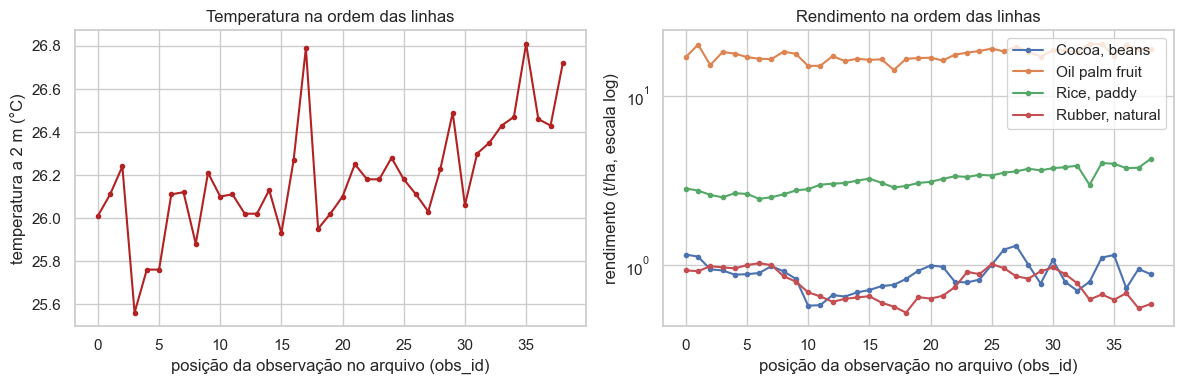

In [11]:
figura, (esquerda, direita) = plt.subplots(1, 2, figsize=FIG_LARGA)

esquerda.plot(clima_39.index, clima_39[COL_TEMPERATURA], marker="o", markersize=3, color="firebrick")
esquerda.set_title("Temperatura na ordem das linhas")
esquerda.set_xlabel("posição da observação no arquivo (obs_id)")
esquerda.set_ylabel("temperatura a 2 m (°C)")

for cultura, g in df.groupby("Crop"):
    ordenado = g.sort_values("obs_id")
    direita.plot(ordenado["obs_id"], ordenado["Yield_t_ha"], marker="o", markersize=3, label=cultura)
direita.set_yscale("log")
direita.set_title("Rendimento na ordem das linhas")
direita.set_xlabel("posição da observação no arquivo (obs_id)")
direita.set_ylabel("rendimento (t/ha, escala log)")
direita.legend()

figura.tight_layout()
plt.show()

### A ordem das linhas carrega informação: uma inferência, não um fato documentado

O arquivo **não tem coluna de ano**. Nada nele declara procedência, período ou local.
O que se pode testar é se a ordem das linhas é arbitrária — e ela não é.

A primeira tabela mostra a autocorrelação de defasagem 1 de cada série, com p-valor
obtido por **100.000 permutações aleatórias da própria série**, pela regra
(k+1)/(B+1). Se a ordem fosse arbitrária, o esperado seria autocorrelação em torno de
zero nas oito.

**As oito séries são significativas a 5%**, da menor — o rendimento do dendê
(0,3821, p = 0,016) — à maior, a borracha (0,8879). Sob o limite de Bonferroni
(0,00079), **quatro sobrevivem com folga**: umidade específica, cacau, arroz e
borracha, todas com p ≤ 5×10⁻⁵, no piso de resolução do teste. A umidade relativa
fica **exatamente na fronteira** (p = 7,8×10⁻⁴ contra o limite de 7,9×10⁻⁴, margem de
menos de 2%), de modo que seu veredito depende do sorteio das permutações e não deve
ser tratado como estabelecido. Precipitação, temperatura e dendê não sobrevivem.

Quatro séries com autocorrelação sobrevivendo a uma correção severa já tornam
insustentável a hipótese de ordem aleatória. O caso do cacau é o mais informativo:
sua tendência é praticamente nula (Spearman 0,064), mas sua autocorrelação é 0,590
com p = 5×10⁻⁵. **Há estrutura sequencial mesmo onde não há tendência**, o que
descarta a explicação de que o arquivo estaria apenas ordenado por alguma coluna.

As tendências reforçam a leitura: o arroz sobe monotonicamente (Spearman **0,910**),
a borracha cai (**−0,380**), a umidade específica sobe (**0,795**) e a temperatura
sobe (**0,670**).

### O preço da autocorrelação: o n efetivo

A segunda tabela quantifica o que a autocorrelação custa. Duas séries correlacionadas
no tempo carregam menos informação independente do que o número de pontos sugere; a
fórmula de **Dawdy–Matalas** estima esse tamanho efetivo. Nos 16 pares, o **n_eff vai
de 7,59 a 28,61** — contra um n nominal de 39.

O efeito sobre as contagens da seção anterior é decisivo:

| Critério | com n = 39 | com n_eff |
|---|---|---|
| Pearson significativos a 5% | 5/16 | **2/16** |
| Pearson sob Bonferroni | 2/16 | **0/16** |

Os dois pares do arroz que sobrevivem a Bonferroni **deixam de sobreviver** quando se
desconta a autocorrelação: Rice × Umid. Específica tem n_eff de apenas **8,45** e seu
p vai de 8,4×10⁻⁷ para **0,046**; Rice × Temperatura tem n_eff 17,41 e p vai para
**0,0085**. Nenhum dos dois passa pelo limite de 0,00079.

**Sobrevive um único resultado em todo o notebook:** Oil palm × Umidade Específica na
coluna parcial. Seus resíduos destendenciados têm n_eff de **34,14** — quase o n
nominal, porque destendenciar remove justamente a fonte da autocorrelação — e o
p corrigido é **0,0001**, abaixo do limite de Bonferroni. É o achado estatisticamente
mais sólido do trabalho, e o único.

**O que a ordenação autoriza afirmar:** a ordem das linhas não é aleatória e o
conjunto se comporta como uma sequência de 39 observações de uma mesma área — padrão
**consistente** com uma série anual de região única. **O que não autoriza:** que
sejam 39 anos, quais anos, ou de que região. Daqui em diante, `obs_id` é tratado como
**índice sequencial ordinal**, nunca como ano.

Isso tem consequência direta na seção 5: uma validação cruzada que sorteia
observações ao acaso deixa os vizinhos temporais de cada observação validada dentro
do treino, o que é uma forma branda de vazamento.

---
## 4. Clusterização e cenários discrepantes

A clusterização é feita sobre as **39 linhas climáticas únicas**, não sobre as 156.
Incluir o rendimento nas 156 linhas produziria clusters guiados pela escala do alvo
— o dendê rende ~22x mais que a seringueira — e o agrupamento viraria um detector
de cultura, não de condição climática.

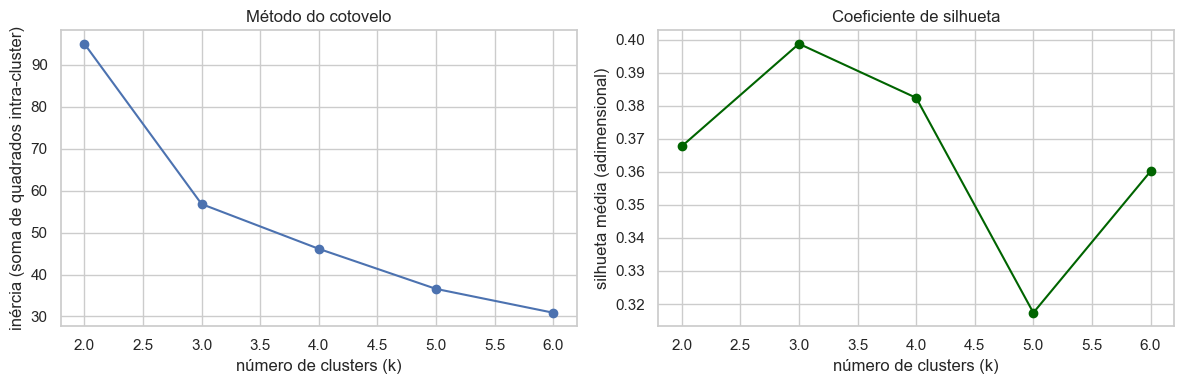

,k,inercia,silhouette
0,2,95.013,0.368
1,3,56.798,0.399
2,4,46.121,0.382
3,5,36.571,0.317
4,6,30.886,0.360


In [12]:
clima_padronizado = StandardScaler().fit_transform(clima_39)

diagnostico_k = []
for k in K_CANDIDATOS:
    modelo = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=N_INICIALIZACOES).fit(clima_padronizado)
    diagnostico_k.append(
        {"k": k, "inercia": modelo.inertia_, "silhouette": silhouette_score(clima_padronizado, modelo.labels_)}
    )
diagnostico_k = pd.DataFrame(diagnostico_k)

figura, (esquerda, direita) = plt.subplots(1, 2, figsize=FIG_LARGA)
esquerda.plot(diagnostico_k["k"], diagnostico_k["inercia"], marker="o")
esquerda.set_title("Método do cotovelo")
esquerda.set_xlabel("número de clusters (k)")
esquerda.set_ylabel("inércia (soma de quadrados intra-cluster)")
direita.plot(diagnostico_k["k"], diagnostico_k["silhouette"], marker="o", color="darkgreen")
direita.set_title("Coeficiente de silhueta")
direita.set_xlabel("número de clusters (k)")
direita.set_ylabel("silhueta média (adimensional)")
figura.tight_layout()
plt.show()

diagnostico_k.round(3)

In [13]:
def nomear_perfis(centroides: pd.DataFrame) -> dict[int, str]:
    """Rótulo derivado do próprio centroide: o índice que o KMeans atribui não é estável."""
    assert len(centroides) == len(ROTULOS_PERFIL), "os rótulos agronômicos só descrevem esta partição"
    chuvoso, quente, ameno = ROTULOS_PERFIL
    mais_chuvoso = centroides[COL_PRECIPITACAO].idxmax()
    restantes = centroides.drop(index=mais_chuvoso)
    return {
        mais_chuvoso: chuvoso,
        restantes[COL_TEMPERATURA].idxmax(): quente,
        restantes[COL_TEMPERATURA].idxmin(): ameno,
    }


agrupador = KMeans(n_clusters=K_CLUSTERS, random_state=RANDOM_STATE, n_init=N_INICIALIZACOES)
clusters_39 = pd.Series(agrupador.fit_predict(clima_padronizado), index=clima_39.index, name="cluster")
perfil_39 = clusters_39.map(nomear_perfis(clima_39.groupby(clusters_39)[COLUNAS_CLIMA].mean())).rename("perfil")

df["perfil"] = df["obs_id"].map(perfil_39)

perfis = clima_39.groupby(perfil_39)[COLUNAS_CLIMA].mean()
perfis["nº de observações"] = perfil_39.value_counts()
perfis["obs_id médio"] = pd.Series(clima_39.index, index=clima_39.index).groupby(perfil_39).mean()
perfis.round(2)

,Precipitation (mm day-1),Specific Humidity at 2 Meters (g/kg),Relative Humidity at 2 Meters (%),Temperature at 2 Meters (C),nº de observações,obs_id médio
perfil,,,,,,
Chuvoso e úmido,2733.52,18.34,85.65,26.12,17,21.53
Seco e ameno,2232.22,17.81,83.92,25.99,11,5.36
Seco e quente,2359.02,18.39,84.15,26.48,11,28.73


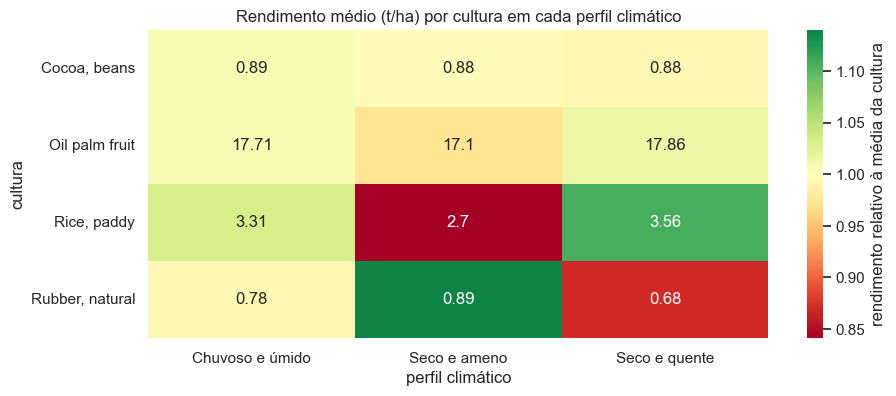

perfil,Chuvoso e úmido,Seco e ameno,Seco e quente
Crop,,,
"Cocoa, beans",0.7,-0.4,-0.7
Oil palm fruit,0.7,-2.7,1.6
"Rice, paddy",3.3,-15.9,10.8
"Rubber, natural",-0.6,13.9,-13.0


In [14]:
rendimento_por_perfil = df.pivot_table(index="Crop", columns="perfil", values="Yield_t_ha", aggfunc="mean")
# Denominador e a media da cultura sobre as 39 observacoes, nao a media das medias de
# perfil: os perfis tem tamanhos diferentes e a media nao ponderada desloca a tabela.
relativo = rendimento_por_perfil.div(MEDIA_POR_CULTURA, axis=0)

figura, eixo = plt.subplots(figsize=FIG_PADRAO)
sns.heatmap(
    relativo,
    annot=rendimento_por_perfil.round(2),
    fmt="g",
    cmap="RdYlGn",
    center=1.0,
    cbar_kws={"label": "rendimento relativo à média da cultura"},
    ax=eixo,
)
eixo.set_title("Rendimento médio (t/ha) por cultura em cada perfil climático")
eixo.set_xlabel("perfil climático")
eixo.set_ylabel("cultura")
plt.show()

(relativo - 1).mul(100).round(1)

In [15]:
kruskal_perfis = pd.Series(
    {
        cultura: stats.kruskal(*[g["Yield_t_ha"].to_numpy() for _, g in sub.groupby("perfil")]).pvalue
        for cultura, sub in df.groupby("Crop")
    },
    name="p_kruskal",
)

print(f"Kruskal-Wallis do rendimento entre perfis climaticos:")
print(kruskal_perfis.map("{:.2e}".format).to_string())
print(f"\nlimite de Bonferroni ({limite_bonferroni:.5f}) — sobrevivem: "
      f"{kruskal_perfis[kruskal_perfis < limite_bonferroni].index.tolist()}")
print(f"significativas a {ALFA:.0%} sem correcao: {kruskal_perfis[kruskal_perfis < ALFA].index.tolist()}")

Kruskal-Wallis do rendimento entre perfis climaticos:
Cocoa, beans       9.53e-01
Oil palm fruit     4.76e-01
Rice, paddy        2.99e-05
Rubber, natural    3.90e-03

limite de Bonferroni (0.00079) — sobrevivem: ['Rice, paddy']
significativas a 5% sem correcao: ['Rice, paddy', 'Rubber, natural']


### Três perfis climáticos, e uma advertência sobre o que eles significam

A silhueta é máxima em **k = 3 (0,399)** e a inércia cai de 95,0 para 56,8 entre
k = 2 e k = 3, com ganho bem menor depois. Os dois critérios apontam para o mesmo k.

Os centroides recebem nome pelo próprio perfil, não pelo índice que o KMeans
atribui — o índice não é estável entre execuções ou versões:

| Perfil | n | Precipitação | Umid. específica | Temperatura | `obs_id` médio |
|---|---|---|---|---|---|
| Chuvoso e úmido | 17 | 2.733,5 mm | 18,34 g/kg | 26,12 °C | 21,5 |
| Seco e ameno | 11 | 2.232,2 mm | 17,81 g/kg | 25,99 °C | **5,4** |
| Seco e quente | 11 | 2.359,0 mm | 18,39 g/kg | 26,48 °C | **28,7** |

O rendimento relativo à média de cada cultura mostra respostas de sinal oposto:

- **Arroz** — o mais sensível: **−15,9%** no perfil *Seco e ameno* e **+10,8%** no
  *Seco e quente*.
- **Borracha** — resposta invertida: **+13,9%** no *Seco e ameno* e **−13,0%** no
  *Seco e quente*.
- **Cacau** — indiferente: entre −0,7% e +0,7%.
- **Dendê** — pouco sensível: entre −2,7% e +1,6%.

**Só o arroz resiste à correção para multiplicidade.** O Kruskal-Wallis dá
p = 3,0×10⁻⁵ para o arroz e p = 3,9×10⁻³ para a borracha; a 5% sem correção ambos são
significativos, mas sob o limite de Bonferroni do notebook (0,00079) **apenas o arroz
sobrevive** — o p da borracha é cinco vezes maior que o limite. Cacau (p = 0,953) e
dendê (p = 0,476) são indistinguíveis de ruído em qualquer critério. A resposta
bidirecional arroz/borracha, portanto, está estabelecida apenas na metade do arroz.

**A advertência é indispensável.** A coluna `obs_id` médio mostra que os perfis não
são apenas climáticos: o *Seco e ameno* concentra-se no início da sequência (5,4) e o
*Seco e quente* no fim (28,7). Os perfis são, em boa medida, **épocas**. Como o
arroz tem tendência crescente de 0,910 ao longo da mesma sequência, **a diferença de
rendimento entre perfis confunde efeito climático com posição na série e não pode ser
lida como resposta causal ao clima.** O arquivo não contém nenhuma variável que
permita atribuir essa diferença ao clima ou a qualquer outro fator — a atribuição
fica em aberto.

O que a clusterização entrega com segurança é uma **descrição de cenários**: três
regimes climáticos distinguíveis e o desempenho observado de cada cultura em cada um.

### 4.1 Cenários discrepantes

O enunciado pede a identificação de cenários discrepantes. A busca é feita em duas
frentes independentes, porque uma observação pode ser atípica no **clima**, no
**resultado produtivo**, ou nos dois — e cada combinação tem uma leitura agronômica
diferente.

In [16]:
def limites_iqr(serie: pd.Series) -> tuple[float, float]:
    q1, q3 = serie.quantile(QUARTIL_INFERIOR), serie.quantile(QUARTIL_SUPERIOR)
    amplitude = q3 - q1
    return q1 - IQR_FATOR * amplitude, q3 + IQR_FATOR * amplitude


marcacoes_clima = pd.DataFrame(
    {coluna: ~clima_39[coluna].between(*limites_iqr(clima_39[coluna])) for coluna in COLUNAS_CLIMA}
)
variaveis_marcadas = marcacoes_clima.dot(pd.Index(marcacoes_clima.columns) + "; ").str.removesuffix("; ")

print(f"observacoes com ao menos uma variavel fora do IQR: "
      f"{marcacoes_clima.any(axis=1).sum()} de {len(clima_39)}")
print(f"total de marcacoes: {marcacoes_clima.to_numpy().sum()}")
print(f"marcacoes por variavel: {marcacoes_clima.sum().to_dict()}")
print(f"ranking de temperatura (5 maiores):\n"
      f"{clima_39[COL_TEMPERATURA].nlargest(5).to_string()}")

observacoes com ao menos uma variavel fora do IQR: 5 de 39
total de marcacoes: 6
marcacoes por variavel: {'Precipitation (mm day-1)': 0, 'Specific Humidity at 2 Meters (g/kg)': 1, 'Relative Humidity at 2 Meters (%)': 1, 'Temperature at 2 Meters (C)': 4}
ranking de temperatura (5 maiores):
obs_id
35    26.81
17    26.79
38    26.72
29    26.49
34    26.47


In [17]:
# eps derivado da propria nuvem. NearestNeighbors inclui o proprio ponto a distancia
# zero, entao distancias[:, -1] e a distancia ao 3o vizinho distinto.
distancias, _ = NearestNeighbors(n_neighbors=DBSCAN_MIN_AMOSTRAS).fit(clima_padronizado).kneighbors(clima_padronizado)
eps = float(np.percentile(distancias[:, -1], PERCENTIL_EPS))
ruido_dbscan = pd.Series(
    DBSCAN(eps=eps, min_samples=DBSCAN_MIN_AMOSTRAS).fit_predict(clima_padronizado) == -1,
    index=clima_39.index,
    name="dbscan_ruido",
)

outliers_clima = pd.concat([variaveis_marcadas.rename("variaveis_iqr"), ruido_dbscan], axis=1)
outliers_clima = outliers_clima[(outliers_clima["variaveis_iqr"] != "") | outliers_clima["dbscan_ruido"]]

temperaturas = clima_39[COL_TEMPERATURA]
maximos_locais = [
    i for i in outliers_clima.index
    if 0 < i < len(clima_39) - 1 and temperaturas[i] > max(temperaturas[i - 1], temperaturas[i + 1])
]

print(f"eps derivado dos dados: {eps:.3f} | ruido DBSCAN: {ruido_dbscan.sum()} de {len(clima_39)}")
print(f"posicao na sequencia (0 = primeira observacao, 1 = ultima): "
      f"{ {i: round(i / (len(clima_39) - 1), 2) for i in outliers_clima.index} }")
print(f"marcados que sao maximo local estrito de temperatura: {maximos_locais}")
clima_39.loc[outliers_clima.index].join(outliers_clima).round(2)

eps derivado dos dados: 1.617 | ruido DBSCAN: 1 de 39
posicao na sequencia (0 = primeira observacao, 1 = ultima): {1: 0.03, 3: 0.08, 17: 0.45, 35: 0.92, 38: 1.0}
marcados que sao maximo local estrito de temperatura: [17, 35]


,Precipitation (mm day-1),Specific Humidity at 2 Meters (g/kg),Relative Humidity at 2 Meters (%),Temperature at 2 Meters (C),variaveis_iqr,dbscan_ruido
obs_id,,,,,,
1,1938.42,17.54,82.11,26.11,Specific Humidity at 2 Meters (g/kg); Relative...,True
3,2592.35,17.61,85.07,25.56,Temperature at 2 Meters (C),False
17,2362.80,18.70,84.03,26.79,Temperature at 2 Meters (C),False
35,2410.13,18.58,83.45,26.81,Temperature at 2 Meters (C),False
38,2109.34,18.51,83.52,26.72,Temperature at 2 Meters (C),False


In [18]:
def marcar_outliers_rendimento(dados: pd.DataFrame) -> pd.DataFrame:
    """IQR aplicado dentro de cada cultura: a escala entre culturas difere em ~22x."""
    marcados = []
    for cultura, g in dados.groupby("Crop"):
        inferior, superior = limites_iqr(g["Yield_t_ha"])
        fora = g[~g["Yield_t_ha"].between(inferior, superior)]
        marcados.append(fora[["Crop", "obs_id", "Yield_t_ha", "perfil"]].assign(
            limite_inferior=inferior, limite_superior=superior
        ))
    return pd.concat(marcados)


outliers_rendimento = marcar_outliers_rendimento(df)

print(f"outliers de rendimento por IQR dentro da cultura: {len(outliers_rendimento)}")
outliers_rendimento.round(3)

outliers de rendimento por IQR dentro da cultura: 0


,Crop,obs_id,Yield_t_ha,perfil,limite_inferior,limite_superior


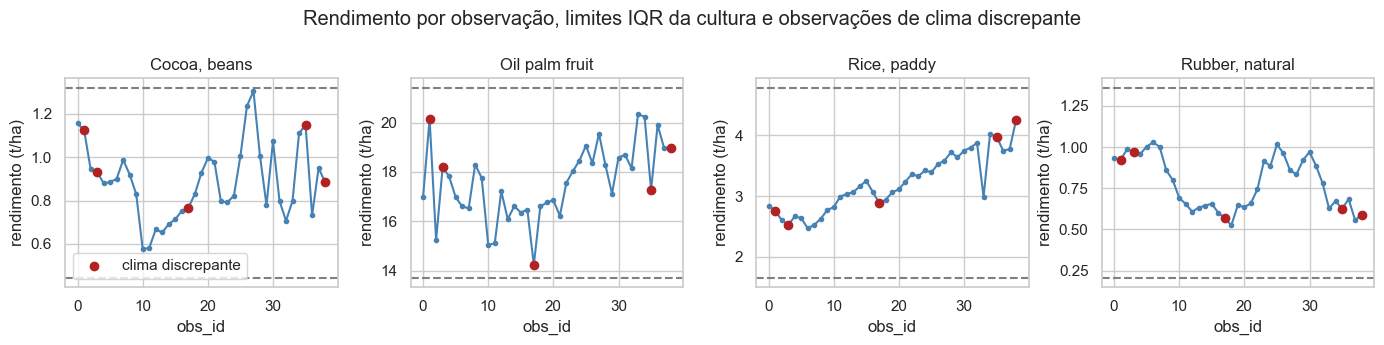

In [19]:
figura, eixos = plt.subplots(1, len(CULTURAS), figsize=FIG_PAINEL)
for eixo, cultura in zip(eixos, CULTURAS):
    sub = df[df["Crop"] == cultura].sort_values("obs_id")
    inferior, superior = limites_iqr(sub["Yield_t_ha"])
    eixo.plot(sub["obs_id"], sub["Yield_t_ha"], marker="o", markersize=3, color="steelblue")
    eixo.axhline(inferior, linestyle="--", color="grey")
    eixo.axhline(superior, linestyle="--", color="grey")
    discrepantes = sub[sub["obs_id"].isin(outliers_clima.index)]
    eixo.scatter(discrepantes["obs_id"], discrepantes["Yield_t_ha"], color="firebrick", zorder=3,
                 label="clima discrepante")
    eixo.set_title(cultura)
    eixo.set_xlabel("obs_id")
    eixo.set_ylabel("rendimento (t/ha)")
eixos[0].legend()
figura.suptitle("Rendimento por observação, limites IQR da cultura e observações de clima discrepante")
figura.tight_layout()
plt.show()

### Leitura dos cenários discrepantes

**Cinco observações climáticas** foram marcadas, somando **seis marcações** — quatro
de temperatura, uma de umidade específica e uma de relativa; a precipitação não
marcou nenhuma. O DBSCAN (`eps = 1,617`, derivado do percentil 90 da distância ao
**terceiro vizinho distinto**, não arbitrado) marcou **uma**. **Nenhum outlier de
rendimento** foi encontrado por IQR dentro de cultura.

| `obs_id` | Posição na sequência | O que foi marcado | Leitura |
|---|---|---|---|
| 1 | 0,03 | Umidade específica (17,54) e relativa (82,11), **e único ruído do DBSCAN** | Observação seca em três frentes simultâneas — precipitação 1.938 mm, as duas umidades no mínimo. As variáveis são **mutuamente coerentes**: baixa precipitação acompanha baixa umidade. Assinatura de **evento climático real**, não de erro de medição, que tipicamente afetaria uma variável isolada. É também o único ponto isolado em quatro dimensões, daí a marcação do DBSCAN. |
| 3 | 0,08 | Temperatura 25,56 °C (mínima) | Observação fria e chuvosa (2.592 mm). Combinação fisicamente coerente. Evento real. |
| 17 | **0,45** | Temperatura 26,79 °C | **Segunda** temperatura mais alta, situada no **meio** da sequência. |
| 35 | 0,92 | Temperatura 26,81 °C | Máxima absoluta, no trecho final. |
| 38 | 1,00 | Temperatura 26,72 °C | Última observação da sequência. |

O grupo 17/35/38 merece atenção metodológica. A temperatura tem tendência crescente
(Spearman 0,670 na seção 3), e dois dos três pontos estão no trecho final (posições
0,92 e 1,00). Quando se aplica IQR a uma série com tendência, o método marca em boa
parte **a cauda da tendência**, não anomalias: esses pontos são "extremos" apenas em
relação à distribuição das 39 observações somadas, e seriam ordinários dentro da
distribuição de seu próprio trecho. Dos três, **17 e 35 são máximos locais estritos**
de temperatura (verificado na saída da célula); o 38, por ser a última observação da
série, não tem vizinho posterior com que se comparar.

**Ausência de outliers de rendimento.** Nenhuma cultura tem valor além de 1,5×IQR
dentro de sua própria distribuição, e as observações de clima discrepante não
correspondem a rendimento discrepante. Convém não superinterpretar esse zero: o mesmo
argumento do parágrafo anterior se aplica ao rendimento — o IQR sobre séries com
tendência (arroz, Spearman 0,910) tende a não marcar nada, de modo que a ausência de
marcação é em parte propriedade do método, não apenas do dado. O que se pode afirmar
com segurança é que **não há, no período coberto, quebra de safra grande o bastante
para escapar da variação normal da cultura pelo critério do IQR**.

**Decisão: nenhuma observação é removida.** Os cinco pontos climáticos são eventos
reais e internamente coerentes, não erros. Remover os mais quentes seria pior que
inócuo: eliminaria justamente o trecho final da série, onde está a maior parte do
sinal climático, e enviesaria o conjunto na direção do início do período.

---
## 5. Modelagem preditiva

Cinco algoritmos em quatro famílias, comparados **contra um piso explícito**, no
mesmo procedimento de validação, e sob **dois desenhos de validação cruzada**: um
que ignora a ordem das observações e outro que a respeita.

In [20]:
class MediaPorCultura(RegressorMixin, BaseEstimator):
    """Prediz a média de treino da cultura, ignorando o clima: é o piso de comparação."""

    def fit(self, X: pd.DataFrame, y: np.ndarray) -> "MediaPorCultura":
        self.medias_ = pd.Series(y, index=X["Crop"].to_numpy()).groupby(level=0).mean()
        self.media_global_ = float(np.mean(y))
        return self

    def predict(self, X: pd.DataFrame) -> np.ndarray:
        return X["Crop"].map(self.medias_).fillna(self.media_global_).to_numpy()


referencia_completa = MediaPorCultura().fit(df, df["Yield_t_ha"].to_numpy())
predicao_referencia = referencia_completa.predict(df)

print(f"R2 in-sample do baseline media-por-cultura nas {len(df)} linhas: "
      f"{r2_score(df['Yield_t_ha'], predicao_referencia):.4f}")
print(f"RMSE in-sample desse baseline: "
      f"{root_mean_squared_error(df['Yield_t_ha'], predicao_referencia):.4f} t/ha")

R2 in-sample do baseline media-por-cultura nas 156 linhas: 0.9876
RMSE in-sample desse baseline: 0.7822 t/ha


### O piso de comparação

Um modelo que ignora o clima por completo e prediz apenas a média histórica de cada
cultura atinge **R² = 0,9876** e RMSE de **0,7822 t/ha** — ambos medidos
**in-sample**, sobre as mesmas 156 linhas em que foram ajustados. Os valores de
validação cruzada desse mesmo baseline aparecem na tabela adiante e são ligeiramente
diferentes (R² CV = 0,9872; RMSE CV = 0,7684); as duas grandezas não devem ser
confundidas.

**Saber apenas qual é a cultura já explica 98,76% da variância do rendimento.** A
origem desse número é específica e vale nomear: **é a distância do dendê às demais**.
Com média de 17,58 t/ha contra 0,78 a 3,21 das outras três, o dendê sozinho responde
por quase toda a variância entre culturas. Cacau e borracha, como a seção 3 mostra,
compartilham quase toda a sua faixa de rendimento — entre essas duas o baseline
praticamente não distingue nada.

Daqui decorre o critério de avaliação deste notebook. Um R² de 0,98 ou 0,99 nas
tabelas seguintes **não indica bom modelo** — indica apenas que o modelo aprendeu a
separar o dendê do resto, coisa que o baseline faz de graça. A única pergunta que
importa é: **quanto cada algoritmo reduz o erro em relação a este piso?**

In [21]:
X = df[["Crop"] + COLUNAS_CLIMA]
y = df["Yield_t_ha"].to_numpy()
grupos = df["obs_id"].to_numpy()

separador = GroupShuffleSplit(n_splits=1, test_size=TESTE_FRACAO, random_state=RANDOM_STATE)
indices_treino, indices_teste = next(separador.split(X, y, groups=grupos))
X_treino, X_teste = X.iloc[indices_treino], X.iloc[indices_teste]
y_treino, y_teste = y[indices_treino], y[indices_teste]
grupos_treino = grupos[indices_treino]

obs_treino, obs_teste = set(grupos[indices_treino]), set(grupos[indices_teste])
print(f"treino: {len(X_treino)} linhas / {len(obs_treino)} observacoes climaticas")
print(f"teste:  {len(X_teste)} linhas / {len(obs_teste)} observacoes climaticas")
print(f"intersecao de obs_id entre treino e teste: {len(obs_treino & obs_teste)}")
print(f"culturas no teste: {X_teste['Crop'].value_counts().to_dict()}")

treino: 124 linhas / 31 observacoes climaticas
teste:  32 linhas / 8 observacoes climaticas
intersecao de obs_id entre treino e teste: 0
culturas no teste: {'Cocoa, beans': 8, 'Oil palm fruit': 8, 'Rice, paddy': 8, 'Rubber, natural': 8}


In [22]:
preprocessador = ColumnTransformer(
    [
        # drop="first" evita colinearidade perfeita nos modelos lineares; e indiferente aos demais.
        ("cultura", OneHotEncoder(drop="first", sparse_output=False), ["Crop"]),
        ("clima", StandardScaler(), COLUNAS_CLIMA),
    ]
)


def montar_estimador(modelo: BaseEstimator) -> TransformedTargetRegressor:
    """Encoder, scaler e log do alvo dentro do estimador: assim tudo e ajustado so no fold de treino."""
    return TransformedTargetRegressor(
        regressor=Pipeline([("preparo", clone(preprocessador)), ("modelo", modelo)]),
        func=np.log,
        inverse_func=np.exp,
    )


# Hiperparametros fixos e conservadores: com 39 observacoes efetivas, gastar folds em
# busca de hiperparametro deixaria a estimativa de erro mais instavel do que o ganho.
MODELOS = {
    "Baseline média/cultura": MediaPorCultura(),
    "Regressão Linear": montar_estimador(LinearRegression()),
    "Ridge": montar_estimador(Ridge(alpha=RIDGE_ALPHA)),
    "KNN": montar_estimador(KNeighborsRegressor(n_neighbors=KNN_VIZINHOS)),
    "Random Forest": montar_estimador(
        RandomForestRegressor(n_estimators=N_ARVORES, random_state=RANDOM_STATE)
    ),
    "Gradient Boosting": montar_estimador(
        GradientBoostingRegressor(n_estimators=N_ARVORES, max_depth=PROFUNDIDADE_GB, random_state=RANDOM_STATE)
    ),
}

In [23]:
def metricas(y_real: np.ndarray, y_predito: np.ndarray) -> dict[str, float]:
    return {
        "RMSE": root_mean_squared_error(y_real, y_predito),
        "MAE": mean_absolute_error(y_real, y_predito),
        "R2": r2_score(y_real, y_predito),
    }


def rmse_por_cultura(culturas: pd.Series, y_real: np.ndarray, y_predito: np.ndarray) -> dict[str, float]:
    erros = pd.DataFrame({"cultura": culturas.to_numpy(), "real": y_real, "predito": y_predito})
    return {
        f"{PREFIXO_RMSE_CULTURA}{cultura}": root_mean_squared_error(g["real"], g["predito"])
        for cultura, g in erros.groupby("cultura")
    }


def avaliar_em_folds(
    estimador: BaseEstimator, X: pd.DataFrame, y: np.ndarray, divisoes: list[tuple[np.ndarray, np.ndarray]]
) -> pd.DataFrame:
    """Uma linha por fold, com métricas globais e RMSE de cada cultura."""
    registros = []
    for indice, (i_treino, i_val) in enumerate(divisoes):
        ajustado = clone(estimador).fit(X.iloc[i_treino], y[i_treino])
        predito = ajustado.predict(X.iloc[i_val])
        registros.append(
            {
                "fold": indice,
                **metricas(y[i_val], predito),
                **rmse_por_cultura(X["Crop"].iloc[i_val], y[i_val], predito),
            }
        )
    return pd.DataFrame(registros)


def folds_em_blocos_temporais(grupos: np.ndarray, n_blocos: int) -> list[tuple[np.ndarray, np.ndarray]]:
    """Cada fold de validação é um trecho contíguo da sequência. Reduz drasticamente,
    mas não elimina, a presença de vizinhos temporais no treino: sobram as bordas."""
    particoes = np.array_split(np.sort(np.unique(grupos)), n_blocos)
    return [(np.flatnonzero(~np.isin(grupos, b)), np.flatnonzero(np.isin(grupos, b))) for b in particoes]


def vizinhos_temporais_no_treino(divisoes: list[tuple[np.ndarray, np.ndarray]], grupos: np.ndarray) -> int:
    """Quantas observações validadas têm o vizinho imediato da sequência no treino."""
    total = 0
    for i_treino, i_val in divisoes:
        no_treino, na_validacao = set(grupos[i_treino]), set(grupos[i_val])
        total += sum(1 for o in na_validacao if {o - 1, o + 1} & no_treino)
    return total

In [24]:
divisoes_intercaladas = list(GroupKFold(n_splits=N_FOLDS).split(X_treino, y_treino, groups=grupos_treino))
divisoes_temporais = folds_em_blocos_temporais(grupos_treino, N_FOLDS)

folds_intercalados = {
    nome: avaliar_em_folds(estimador, X_treino, y_treino, divisoes_intercaladas)
    for nome, estimador in MODELOS.items()
}
folds_temporais = {
    nome: avaliar_em_folds(estimador, X_treino, y_treino, divisoes_temporais)
    for nome, estimador in MODELOS.items()
}
ajustados = {nome: clone(estimador).fit(X_treino, y_treino) for nome, estimador in MODELOS.items()}

for rotulo, divisoes in (("intercalado", divisoes_intercaladas), ("blocos temporais", divisoes_temporais)):
    print(f"{rotulo:17s} observacoes por fold: {[len(set(grupos_treino[v])) for _, v in divisoes]}"
          f" | validadas com vizinho imediato no treino: "
          f"{vizinhos_temporais_no_treino(divisoes, grupos_treino)}/{len(set(grupos_treino))}")

intercalado       observacoes por fold: [7, 6, 6, 6, 6] | validadas com vizinho imediato no treino: 30/31
blocos temporais  observacoes por fold: [7, 6, 6, 6, 6] | validadas com vizinho imediato no treino: 6/31


In [25]:
comparacao = []
for nome in MODELOS:
    intercalado, temporal = folds_intercalados[nome], folds_temporais[nome]
    comparacao.append(
        {
            "modelo": nome,
            "RMSE CV": intercalado["RMSE"].mean(),
            "± dp": intercalado["RMSE"].std(),
            "MAE CV": intercalado["MAE"].mean(),
            "R2 CV": intercalado["R2"].mean(),
            "RMSE blocos": temporal["RMSE"].mean(),
            "± dp blocos": temporal["RMSE"].std(),
            **{f"{k} holdout": v for k, v in metricas(y_teste, ajustados[nome].predict(X_teste)).items()},
        }
    )

comparacao = pd.DataFrame(comparacao).set_index("modelo")
for rotulo, origem in (("ganho CV", "RMSE CV"), ("ganho blocos", "RMSE blocos")):
    piso = comparacao.loc["Baseline média/cultura", origem]
    comparacao[rotulo] = (1 - comparacao[origem] / piso).map(lambda v: f"{v:+.1%}")

comparacao.round(4)

,RMSE CV,± dp,MAE CV,R2 CV,RMSE blocos,± dp blocos,RMSE holdout,MAE holdout,R2 holdout,ganho CV,ganho blocos
modelo,,,,,,,,,,,
Baseline média/cultura,0.7684,0.1451,0.4620,0.9872,0.8362,0.1723,0.9245,0.5808,0.9842,+0.0%,+0.0%
Regressão Linear,0.8907,0.2420,0.5076,0.9824,1.0205,0.2296,0.5047,0.3470,0.9953,-15.9%,-22.0%
Ridge,1.2537,0.3251,0.7222,0.9662,1.3594,0.5433,1.1189,0.7055,0.9768,-63.1%,-62.6%
KNN,4.2323,0.5998,2.0673,0.6170,4.2533,1.7329,4.6853,2.2913,0.5935,-450.8%,-408.6%
Random Forest,0.7232,0.2080,0.3774,0.9884,0.9241,0.2471,1.0414,0.6071,0.9799,+5.9%,-10.5%
Gradient Boosting,0.7902,0.2625,0.4271,0.9859,0.9480,0.3094,0.9254,0.5192,0.9841,-2.8%,-13.4%


In [26]:
# Contrafactual do KNN: o colapso vem de o one-hot entrar sem padronizacao ao lado
# do clima padronizado, nao da familia de algoritmos.
knn_tudo_padronizado = TransformedTargetRegressor(
    regressor=Pipeline(
        [
            ("preparo", clone(preprocessador)),
            ("escala", StandardScaler()),
            ("modelo", KNeighborsRegressor(n_neighbors=KNN_VIZINHOS)),
        ]
    ),
    func=np.log,
    inverse_func=np.exp,
)
rmse_knn_padronizado = avaliar_em_folds(
    knn_tudo_padronizado, X_treino, y_treino, divisoes_intercaladas
)["RMSE"].mean()

print(f"KNN como configurado (one-hot nao padronizado): RMSE CV = {comparacao.loc['KNN', 'RMSE CV']:.4f}")
print(f"KNN com o one-hot tambem padronizado:           RMSE CV = {rmse_knn_padronizado:.4f}")
print(f"piso (baseline):                                RMSE CV = "
      f"{comparacao.loc['Baseline média/cultura', 'RMSE CV']:.4f}")

KNN como configurado (one-hot nao padronizado): RMSE CV = 4.2323
KNN com o one-hot tambem padronizado:           RMSE CV = 1.4296
piso (baseline):                                RMSE CV = 0.7684


### O resultado depende do desenho da validação — e essa é a descoberta

O baseline entra na tabela como competidor, avaliado pelos mesmos procedimentos. As
duas colunas de ganho comparam os mesmos modelos, sobre as mesmas 31 observações de
treino e com folds do mesmo tamanho (7, 6, 6, 6, 6), diferindo apenas em **como** os
folds são formados:

| Modelo | RMSE CV intercalada | ganho | RMSE CV em blocos | ganho |
|---|---|---|---|---|
| Baseline média/cultura | 0,7684 | — | 0,8362 | — |
| **Random Forest** | **0,7232** | **+5,9%** | 0,9241 | **−10,5%** |
| Gradient Boosting | 0,7902 | −2,8% | 0,9480 | −13,4% |
| Regressão Linear | 0,8907 | −15,9% | 1,0205 | −22,0% |
| Ridge | 1,2537 | −63,1% | 1,3594 | −62,6% |
| KNN | 4,2323 | −450,8% | 4,2533 | −408,6% |

Na **validação intercalada** — o `GroupKFold` padrão, que sorteia observações sem
olhar a ordem — apenas o Random Forest fica acima do piso, por 5,9%. Os outros quatro
ficam abaixo.

Na **validação em blocos temporais** — em que cada fold de validação é um trecho
contíguo da sequência — nenhum dos cinco fica acima do piso, e o Random Forest passa
de +5,9% para **−10,5%**.

A explicação está na seção 3, e o número que a sustenta está impresso duas células
acima: no desenho intercalado, **30 das 31** observações validadas têm seu vizinho
imediato da sequência dentro do treino; no desenho em blocos, apenas **6 das 31** —
as bordas dos blocos. Com autocorrelação de até 0,888, o desenho intercalado permite
que o modelo interpole dentro de um trecho que já viu; o desenho em blocos exige
extrapolar para um trecho inteiro não observado. Os dois são defensáveis; o segundo é
o que corresponde à estrutura que a seção 3 documentou.

**A leitura honesta, aplicada aos dois lados com o mesmo rigor.** Nem o +5,9% nem o
−10,5% são distinguíveis de zero: o teste t pareado sobre os ganhos fold a fold dá
**p = 0,403** no desenho intercalado e **p = 0,391** em blocos, e em ambos o desvio
entre folds supera a média em magnitude. O que os dados sustentam **não** é que o
modelo piora sob blocos; é que **nenhum dos dois desenhos produz evidência de que
qualquer um dos cinco algoritmos aprenda algo sobre clima que o conhecimento da
cultura já não entregue** — e que a direção do efeito é sensível a uma escolha de
desenho, o que por si só desaconselha afirmar ganho.

Repare no que aconteceria sem o baseline na tabela: a Regressão Linear exibe R² CV de
**0,9824** e o Gradient Boosting **0,9859**. Isolados, esses números pareceriam
excelentes. Comparados ao piso, ficam abaixo dele nos dois desenhos. É exatamente
esse erro de leitura que o baseline existe para impedir.

**Sobre o KNN.** O colapso não é propriedade da família de algoritmos, e sim da
configuração adotada aqui: após o `ColumnTransformer`, a cultura vira três colunas
binárias **não padronizadas** enquanto o clima é padronizado, de modo que a distância
euclidiana mistura as duas escalas. O contrafactual medido acima confirma:
padronizando também o one-hot, o RMSE CV do KNN cai de **4,2323 para 1,4296**.
Continua abaixo do piso (0,7684), então o ranking não muda — mas a explicação correta
é de pré-processamento, não de método.

In [27]:
melhor_modelo = comparacao.drop(index="Baseline média/cultura")["RMSE CV"].idxmin()
colunas_cultura = [c for c in folds_intercalados[melhor_modelo].columns if c.startswith(PREFIXO_RMSE_CULTURA)]

por_cultura = pd.DataFrame(
    {
        "RMSE CV": folds_intercalados[melhor_modelo][colunas_cultura].mean(),
        "dp entre folds": folds_intercalados[melhor_modelo][colunas_cultura].std(),
        "RMSE baseline CV": folds_intercalados["Baseline média/cultura"][colunas_cultura].mean(),
        "RMSE blocos": folds_temporais[melhor_modelo][colunas_cultura].mean(),
        "RMSE baseline blocos": folds_temporais["Baseline média/cultura"][colunas_cultura].mean(),
    }
)
por_cultura["rendimento médio (t/ha)"] = [
    MEDIA_POR_CULTURA[c.removeprefix(PREFIXO_RMSE_CULTURA)] for c in por_cultura.index
]
por_cultura["RMSE / rendimento"] = por_cultura["RMSE CV"] / por_cultura["rendimento médio (t/ha)"]
por_cultura["ganho CV"] = 1 - por_cultura["RMSE CV"] / por_cultura["RMSE baseline CV"]
por_cultura["ganho blocos"] = 1 - por_cultura["RMSE blocos"] / por_cultura["RMSE baseline blocos"]

print(f"melhor modelo por RMSE de validacao cruzada intercalada: {melhor_modelo}")
por_cultura.round(4)

melhor modelo por RMSE de validacao cruzada intercalada: Random Forest


,RMSE CV,dp entre folds,RMSE baseline CV,RMSE blocos,RMSE baseline blocos,rendimento médio (t/ha),RMSE / rendimento,ganho CV,ganho blocos
"RMSE por cultura: Cocoa, beans",0.1333,0.0302,0.1569,0.2114,0.1627,0.8883,0.1500,0.1503,-0.2991
RMSE por cultura: Oil palm fruit,1.3825,0.4414,1.4382,1.7637,1.5539,17.5805,0.0786,0.0387,-0.1350
"RMSE por cultura: Rice, paddy",0.3419,0.1227,0.4690,0.4527,0.5126,3.2100,0.1065,0.2710,0.1170
"RMSE por cultura: Rubber, natural",0.1224,0.0365,0.1534,0.1832,0.1803,0.7825,0.1564,0.2022,-0.0159


In [28]:
ganhos = {
    "intercalado": folds_intercalados["Baseline média/cultura"]["RMSE"] - folds_intercalados[melhor_modelo]["RMSE"],
    "blocos temporais": folds_temporais["Baseline média/cultura"]["RMSE"] - folds_temporais[melhor_modelo]["RMSE"],
}
for rotulo, ganho in ganhos.items():
    p_pareado = stats.ttest_1samp(ganho, 0).pvalue
    print(f"{rotulo:17s} ganho fold a fold: {ganho.round(3).tolist()} | media {ganho.mean():+.4f} t/ha"
          f" | dp {ganho.std():.4f} | vence o piso em {(ganho > 0).sum()}/{N_FOLDS}"
          f" | t pareado p = {p_pareado:.4f}")

intercalado       ganho fold a fold: [0.138, 0.021, 0.105, 0.096, -0.133] | media +0.0452 t/ha | dp 0.1083 | vence o piso em 4/5 | t pareado p = 0.4031
blocos temporais  ganho fold a fold: [-0.313, 0.227, -0.027, -0.196, -0.129] | media -0.0878 t/ha | dp 0.2044 | vence o piso em 1/5 | t pareado p = 0.3910


### Onde o erro está, e onde a mudança de desenho morde

Desagregado por cultura, o Random Forest nos dois desenhos:

| Cultura | RMSE CV | dp entre folds | ganho CV | RMSE blocos | ganho blocos | RMSE / rendimento |
|---|---|---|---|---|---|---|
| Cacau | 0,1333 | 0,0302 | +15,0% | 0,2114 | **−29,9%** | 15,0% |
| Dendê | 1,3825 | 0,4414 | +3,9% | 1,7637 | **−13,5%** | 7,9% |
| Arroz | 0,3419 | 0,1227 | **+27,1%** | 0,4527 | **+11,7%** | 10,6% |
| Borracha | 0,1224 | 0,0365 | +20,2% | 0,1832 | −1,6% | 15,6% |

Três leituras que a métrica global esconderia:

1. **O RMSE global é uma métrica do dendê.** O erro absoluto do dendê (1,38 t/ha) é
   dez vezes o da borracha (0,12), mas em termos relativos o dendê é a cultura **mais
   bem** predita (7,9% do rendimento médio) e a borracha a **pior** (15,6%). A ordem
   se inverte quando se corrige pela escala.
2. **O ganho intercalado concentra-se no arroz** (+27,1%, contra 3,9% a 20,2% nas
   demais) — a cultura com a tendência temporal mais forte (Spearman 0,910).
3. **Mas o colapso sob blocos não vem do arroz.** Ao contrário: o arroz é a **única
   cultura que mantém ganho positivo** no desenho em blocos (+11,7%). Quem derruba a
   média são o cacau (−29,9%) e o dendê (−13,5%). Uma hipótese natural seria que o
   modelo usasse o clima como proxy da posição na série, e que o proxy falhasse ao
   validar em trechos inteiros não observados — **os números não sustentam essa
   atribuição** e ela não é feita aqui. O que se observa é que a mudança de desenho
   afeta cada cultura de forma diferente, sem que o arquivo contenha variáveis que
   permitam explicar por quê.

A comparação pareada fold a fold confirma a fragilidade de ambos os resultados:
intercalado `[0,138; 0,021; 0,105; 0,096; −0,133]`, média **+0,0452** com dp
**0,1083** e t pareado **p = 0,403**; blocos `[−0,313; 0,227; −0,027; −0,196;
−0,129]`, média **−0,0878** com dp **0,2044** e **p = 0,391**. Em ambos, a dispersão
entre folds supera a média, e em cada desenho existe ao menos um fold que contraria o
sinal agregado. Com cinco folds de 6 a 7 observações climáticas cada, nenhum teste
teria poder para decidir a questão — e é isso que os dois p-valores dizem.

In [29]:
predito_holdout = ajustados[melhor_modelo].predict(X_teste)
residuos_holdout = y_teste - predito_holdout

erro_bruto = pd.Series(residuos_holdout**2, index=X_teste["Crop"].to_numpy())
erro_log = pd.Series((np.log(y_teste) - np.log(predito_holdout)) ** 2, index=X_teste["Crop"].to_numpy())

assimetria_escala = pd.DataFrame(
    {
        "share do erro² em t/ha": erro_bruto.groupby(level=0).sum() / erro_bruto.sum(),
        "share do erro² em log": erro_log.groupby(level=0).sum() / erro_log.sum(),
    }
)

estatistica_shapiro, p_shapiro = stats.shapiro(residuos_holdout)
print(f"Shapiro-Wilk nos residuos do holdout: W={estatistica_shapiro:.3f} p={p_shapiro:.6f}"
      f" (n={len(residuos_holdout)} linhas, mas apenas {len(obs_teste)} observacoes climaticas)")
print("O modelo minimiza o erro no espaco log e e avaliado em t/ha:")
assimetria_escala.round(4)

Shapiro-Wilk nos residuos do holdout: W=0.775 p=0.000014 (n=32 linhas, mas apenas 8 observacoes climaticas)
O modelo minimiza o erro no espaco log e e avaliado em t/ha:


,share do erro² em t/ha,share do erro² em log
"Cocoa, beans",0.0128,0.3872
Oil palm fruit,0.9236,0.0787
"Rice, paddy",0.0545,0.1479
"Rubber, natural",0.0091,0.3862


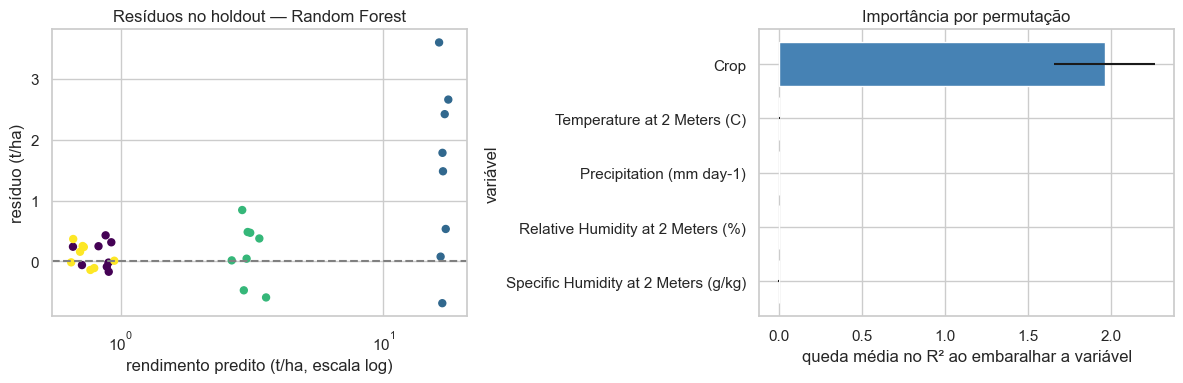

Crop                                    1.9626
Temperature at 2 Meters (C)             0.0024
Precipitation (mm day-1)                0.0001
Relative Humidity at 2 Meters (%)       0.0000
Specific Humidity at 2 Meters (g/kg)   -0.0008

razao entre a cultura e a melhor variavel climatica: 807x


In [30]:
importancias = permutation_importance(
    ajustados[melhor_modelo], X_teste, y_teste, n_repeats=N_REPETICOES_IMPORTANCIA, random_state=RANDOM_STATE
)

figura, (esquerda, direita) = plt.subplots(1, 2, figsize=FIG_LARGA)
esquerda.scatter(predito_holdout, residuos_holdout,
                 c=[CULTURAS.index(c) for c in X_teste["Crop"]], cmap="viridis", s=25)
esquerda.axhline(0, color="grey", linestyle="--")
esquerda.set_xscale("log")
esquerda.set_title(f"Resíduos no holdout — {melhor_modelo}")
esquerda.set_xlabel("rendimento predito (t/ha, escala log)")
esquerda.set_ylabel("resíduo (t/ha)")

ordem = np.argsort(importancias.importances_mean)
direita.barh(np.array(X_teste.columns)[ordem], importancias.importances_mean[ordem],
             xerr=importancias.importances_std[ordem], color="steelblue")
direita.set_title("Importância por permutação")
direita.set_xlabel("queda média no R² ao embaralhar a variável")
direita.set_ylabel("variável")
figura.tight_layout()
plt.show()

ranking = pd.Series(importancias.importances_mean, index=X_teste.columns).sort_values(ascending=False)
print(ranking.round(4).to_string())
print(f"\nrazao entre a cultura e a melhor variavel climatica: {ranking.iloc[0] / ranking.iloc[1]:.0f}x")

### O modelo é um classificador de cultura com ruído climático

A importância por permutação é inequívoca:

| Variável | Queda média no R² ao ser embaralhada |
|---|---|
| **Crop** | **1,9626** |
| Temperature at 2 Meters | 0,0024 |
| Precipitation | 0,0001 |
| Relative Humidity | 0,0000 |
| Specific Humidity | −0,0008 |

A cultura é **807 vezes** mais importante que a melhor variável climática. A umidade
específica tem importância **negativa** — embaralhá-la melhora ligeiramente a
predição, sinal de que o modelo estava usando ruído. Este é o mesmo achado da seção 3
(R² médio de ~9% intra-cultura) confirmado por um caminho independente: **o modelo
prediz o rendimento porque sabe qual é a cultura, não porque entende o clima.**

**Assimetria entre o espaço de ajuste e o espaço de reporte.** O
`TransformedTargetRegressor` minimiza o erro em **log**, mas todas as métricas deste
notebook são reportadas em **t/ha**. Os dois espaços discordam sobre qual cultura
domina o erro:

| Cultura | share do erro² em t/ha | share do erro² em log |
|---|---|---|
| Dendê | **92,4%** | 7,9% |
| Arroz | 5,5% | 14,8% |
| Cacau | 1,3% | **38,7%** |
| Borracha | 0,9% | **38,6%** |

Em escala bruta o dendê responde por **92,4%** do erro quadrático; em log, cai para
7,9%, e cacau e borracha passam a responder por quase 40% cada. **O modelo otimiza
uma coisa e é avaliado por outra.** A escolha é deliberada — o log impede que o ajuste
ignore as três culturas de menor escala, e o reporte em t/ha mantém a métrica
interpretável — mas a assimetria precisa ser nomeada: os ganhos percentuais da tabela
de comparação são medidos no espaço que favorece o dendê.

O teste de Shapiro-Wilk nos resíduos do holdout rejeita a normalidade
(**W = 0,775, p = 0,000014**). Duas ressalvas sobre esse teste. A primeira: ele foi
aplicado a 32 linhas que correspondem a apenas **8 observações climáticas** repetidas
para 4 culturas, de modo que o n efetivo é 8 e não 32 — o mesmo erro de contagem que
a seção 3 combate. A segunda: o gráfico à esquerda mostra a causa da rejeição — os
resíduos formam grupos por cultura, com dispersões de escala muito diferente. É
heterocedasticidade por construção do conjunto, não defeito de ajuste; com quatro
culturas de escala 22× no mesmo conjunto, o teste rejeitaria qualquer modelo. A
consequência prática é que **intervalos de predição paramétricos calculados sobre
estes resíduos agregados não seriam válidos**; intervalos por cultura, ou por
reamostragem, seriam o caminho correto — fora do escopo desta fase.

---
## 6. Conclusão e limitações

### Achados

**1. Nenhum modelo produz evidência de ganho sobre o piso de comparação.** Prever a
média histórica da cultura, ignorando o clima, dá R² in-sample de 0,9876
(R² CV = 0,9872) e RMSE CV de 0,7684 t/ha. Contra esse piso, sob os dois desenhos de
validação:

| Modelo | Ganho — CV intercalada | Ganho — CV em blocos temporais |
|---|---|---|
| Random Forest | **+5,9%** | **−10,5%** |
| Gradient Boosting | −2,8% | −13,4% |
| Regressão Linear | −15,9% | −22,0% |
| Ridge | −63,1% | −62,6% |
| KNN | −450,8% | −408,6% |

Na validação intercalada, um único dos cinco algoritmos fica acima do piso; na
validação em blocos temporais, nenhum. **Nem o +5,9% nem o −10,5% são distinguíveis
de zero** — teste t pareado sobre os ganhos fold a fold dá p = 0,403 e p = 0,391, com
desvio entre folds maior que a média em ambos. A conclusão defensável não é que o
modelo ajuda nem que atrapalha, mas que **o sinal muda de direção conforme uma
escolha de desenho de validação, e nenhum dos dois lados tem poder estatístico para
decidir**. O R² de 0,9884 do Random Forest, isolado, pareceria excelente; medido
contra o que já se sabia sem ele, não sustenta afirmação alguma.

**2. O clima explica pouco — com uma exceção que merece nome.** Dentro de cada
cultura, o R² implícito médio das correlações clima × rendimento é **0,091**, caindo
para **0,058** ao controlar a tendência temporal. A correlação mais forte do conjunto
— arroz × umidade específica, 0,697 — é espúria: colapsa para −0,141 sob controle
temporal, e sob correção por autocorrelação (n_eff = 8,45) seu p vai de 8,4×10⁻⁷ para
0,046. Sob Bonferroni para os 63 testes do notebook **e** correção por
autocorrelação, **zero dos 16 pares brutos sobrevive**.

A exceção é **Oil palm × Umidade Específica na correlação parcial**: r = −0,634,
**R² = 0,4025**, p = 1,9×10⁻⁵, com n_eff de 34,14 e p corrigido de 0,0001. É o
**único resultado do notebook que sobrevive simultaneamente a Bonferroni, ao controle
temporal e à correção por autocorrelação** — e é invisível na correlação bruta (0,071,
p = 0,670), aparecendo apenas depois de removida a tendência. A afirmação "o clima
explica pouco" descreve corretamente a média dos 16 pares, mas não este par. Uma
relação negativa entre umidade específica destendenciada e rendimento do dendê é o
único candidato a sinal climático real neste conjunto, e mereceria investigação
dedicada com dados de manejo — fora do escopo desta fase.

A importância por permutação confirma o quadro geral por outra via: a cultura pesa
**807×** mais que a melhor variável climática.

**3. O vazamento entre culturas foi evitado.** Como as quatro culturas compartilham a
mesma sequência climática, um `train_test_split` comum colocaria a mesma observação
de clima nos dois lados da separação. Usando `GroupShuffleSplit` e `GroupKFold` sobre
`obs_id`, a **interseção de observações climáticas entre treino e teste é 0**, e a
divisão por cultura sai equilibrada por construção (8 linhas de cada cultura no
teste).

**4. Três perfis climáticos descrevem cenários, não causas.** A silhueta seleciona
k = 3 (0,399). Arroz e borracha respondem em sentidos opostos entre os perfis
(−15,9%/+10,8% e +13,9%/−13,0%), mas sob a correção de Bonferroni do notebook
**apenas o arroz é distinguível de ruído** (Kruskal-Wallis p = 3,0×10⁻⁵; a borracha,
p = 3,9×10⁻³, fica cinco vezes acima do limite). Cacau (p = 0,953) e dendê (p = 0,476)
são indiferentes. E os perfis concentram-se em trechos distintos da sequência
(`obs_id` médio 5,4 contra 28,7), de modo que essas diferenças **confundem clima com
posição na série** e não estabelecem relação causal.

**5. Cenários discrepantes.** Cinco observações climáticas atípicas, somando seis
marcações — uma seca coerente em três variáveis simultâneas (`obs_id` 1, também único
ruído do DBSCAN), uma observação fria (`obs_id` 3) e três de temperatura alta
(`obs_id` 17, 35 e 38, das quais duas no trecho final, portanto em parte cauda da
tendência de aquecimento). **Nenhum outlier de rendimento** dentro de cultura — com a
ressalva de que o IQR sobre séries com tendência tende a não marcar nada, de modo que
essa ausência é em parte propriedade do método. Nenhuma observação foi removida.

### Pontos fortes

**Piso de comparação explícito.** Toda métrica é julgada contra o baseline
média-por-cultura, não contra zero. Sem ele, os R² de 0,98–0,99 deste notebook
pareceriam excelentes; com ele, revelam-se marginais ou negativos. É a decisão
metodológica que sustenta todas as conclusões.

**Ausência de vazamento, demonstrada e não apenas afirmada.** A estrutura cruzada do
arquivo é verificada por `assert` antes de ser usada, e a interseção nula de `obs_id`
entre treino e teste é impressa na saída da célula.

**Dois desenhos de validação em vez de um.** Reportar apenas a validação intercalada
teria produzido um resultado positivo e frágil. A comparação com blocos temporais —
com a métrica que a justifica: 30 de 31 observações validadas têm vizinho imediato no
treino sob o desenho intercalado, contra 6 de 31 sob blocos — é o achado mais
informativo do trabalho, e só existe porque a estrutura sequencial detectada na
seção 3 foi levada às consequências na seção 5.

**Controle de tendência e correção por autocorrelação.** A correlação parcial na
posição da observação separa relação climática de co-tendência; o n efetivo de
Dawdy–Matalas quantifica o quanto a autocorrelação infla a significância. É a
combinação dos dois que transforma o "0,697 do arroz" de achado em artefato — e que
isola o único par que resiste.

**Correção para multiplicidade e reporte de dispersão.** Os 63 testes são contados e
o limite de Bonferroni é aplicado às três colunas de p-valor; as métricas de validação
vêm com desvio entre folds, ganho pareado fold a fold e teste t em ambos os desenhos.

**Reprodutibilidade.** `RANDOM_STATE = 42` é declarado uma vez e propagado a todos os
pontos estocásticos, inclusive ao gerador local do teste de permutação, de modo que
cada célula é idempotente e o notebook é determinístico entre execuções.

### Limitações

**Tamanho amostral efetivo.** São **39 observações, não 156** — e, uma vez descontada
a autocorrelação, o n efetivo dos pares fica entre **7,59 e 28,61**. As variáveis
climáticas se repetem idênticas para as quatro culturas, então o arquivo tem quatro
réplicas de 39 pontos de informação climática. Cada fold de validação contém de **6 a
7** observações climáticas.

**Inferência estatística no limite do que o dado suporta.** As séries são fortemente
autocorrelacionadas (lag-1 de 0,382 a 0,888, todas significativas a 5% por permutação;
quatro sobrevivem a Bonferroni com folga e uma quinta fica na fronteira). Os p-valores
das tabelas são brutos; apenas as linhas de Bonferroni e a tabela de n efetivo aplicam
correção. Duas das quatro variáveis climáticas têm assimetria moderada (−0,723 e
−0,553), o que enfraquece o pressuposto de normalidade do Pearson — o Spearman está
reportado ao lado e diverge em um dos pares.

**Assimetria entre ajuste e avaliação.** O alvo é modelado em log, mas as métricas são
reportadas em t/ha, e nos dois espaços a distribuição do erro é quase oposta — o dendê
responde por 92,4% do erro quadrático em escala bruta e por 7,9% em log. Os ganhos
percentuais são medidos no espaço que favorece a cultura de maior escala.

**Ausência de variáveis de manejo e de solo.** O conjunto não traz área plantada,
cultivar, adubação, irrigação, idade do plantio, incidência de pragas nem qualquer
atributo de solo — pH, textura, matéria orgânica, nutrientes. Para culturas perenes
como cacau, dendê e seringueira, a **idade do plantio** é determinante do rendimento e
está inteiramente ausente. A tendência de longo prazo que domina o arroz não pode ser
atribuída a nenhum fator com base neste arquivo, e o comportamento das culturas sob os
dois desenhos de validação também não — faltam as variáveis que explicariam.

**A unidade e a natureza da série são inferências.** A conversão hg/ha → t/ha apoia-se
na plausibilidade agronômica das médias resultantes e na convenção do FAOSTAT, não em
documentação do arquivo. Do mesmo modo, a ordenação sequencial é sustentada por
autocorrelação significativa, o que é **consistente** com uma série anual de região
única — mas o arquivo não tem coluna de ano e nada nele declara período ou
procedência. Nenhuma das duas coisas é afirmada como fato.

**Não generalização.** Os dados descrevem quatro culturas em uma única área, ao longo
de uma única sequência de 39 observações, com amplitude térmica de pouco mais de um
grau. Nada aqui autoriza extrapolação para outras culturas, outras regiões, outros
regimes climáticos, ou para faixas de temperatura e precipitação fora das observadas.
O modelo final não é uma ferramenta de predição climática de safra: é, como a
importância por permutação demonstra, **um classificador de cultura com uma pequena
correção climática por cima** — correção cuja utilidade os dados não conseguem
confirmar nem refutar.

**Resíduos não normais.** Shapiro-Wilk rejeita a normalidade (W = 0,775,
p = 0,000014) por heterocedasticidade entre culturas, o que invalida intervalos de
predição paramétricos construídos sobre os resíduos agregados. O próprio teste, note,
foi aplicado a 32 linhas que correspondem a apenas 8 observações climáticas.